In [52]:
import numpy as np
import matplotlib.pyplot as plt

## Scenario 1

### Tasks

1. Implement ideal sinc reconstruction.
2. Determine the sampling period from `sample_times`.
3. Add a function

```python
def sampling_status(fs):
    ...
```

that returns `"safe"` if Nyquist is satisfied and `"aliased"` otherwise.
4. For

```text
fs = 1200 Hz
fs = 700 Hz
```

predict what will happen.
5. Modify the reconstruction code so that it works for complex-valued samples too.
6. The engineer says:

> “At \(700\) Hz the reconstructed curve still looks smooth, therefore there is no aliasing.”

Explain the exact conceptual error.


In [53]:
def vibration_signal(t):
    return (
        1.5 * np.cos(2*np.pi*120*t)
        + 0.8 * np.sin(2*np.pi*310*t)
        + 0.3 * np.cos(2*np.pi*420*t)
    )

def sample_signal(signal, fs, duration):
    ts = np.arange(0, duration, 1/fs)
    xs = signal(ts)
    return ts, xs

def reconstruct(samples, sample_times, output_times):
    samples = np.asarray(samples)
    sample_times = np.asarray(sample_times)
    output_times = np.asarray(output_times)

    if len(sample_times) < 2:
        raise ValueError("Need at least two samples")

    T = sample_times[1] - sample_times[0]

    kernel = np.sinc(
        (output_times[:, None] - sample_times[None, :]) / T
    )

    return kernel @ samples


def sampling_status(fs):
    f_max = 420.0

    if fs > 2 * f_max:
        return "safe"

    return "aliased"

def run_monitor(fs):
    duration = 0.05

    ts, xs = sample_signal(vibration_signal, fs, duration)

    tdense = np.linspace(0, duration, 6000)
    xr = reconstruct(xs, ts, tdense)

    return tdense, xr

### Explanation 

This function implements the **Whittaker–Shannon interpolation formula** to reconstruct a continuous bandlimited signal from discrete samples at any arbitrary set of evaluation timestamps (`output_times`).

---

**Step-by-Step Breakdown**

* **Determines the Sampling Period ($T$):**
`T = sample_times[1] - sample_times[0]` calculates the time spacing between consecutive samples, assuming uniform sampling.
* **Builds the 2D Sinc Kernel Matrix:**
`output_times[:, None] - sample_times[None, :]` uses NumPy broadcasting to create an $(M, N)$ distance matrix, where $M$ is the number of target query times and $N$ is the number of original samples.
Passing this matrix to `np.sinc(... / T)` evaluates the normalized sinc kernel:

$$\text{sinc}(u) = \frac{\sin(\pi u)}{\pi u}, \quad \text{where } u = \frac{t_{\text{output}} - t_{\text{sample}}}{T}$$




#### Kernel Matrix

```python

    kernel = np.sinc(
        (output_times[:, None] - sample_times[None, :]) / T
    )
```

The kernel matrix is an **influence table**. It measures how much every original sample point influences every single query point you want to calculate.

---

**1. The Broadcasting Trick (`[:, None]` vs `[None, :]`)**

Assume you have 2 original samples at $t = [0, 1]$ and you want to reconstruct the signal at 3 query times $t = [0.0, 0.5, 1.0]$ with $T = 1$:

* `output_times[:, None]` turns your 3 query points into a **column vector** of shape `(3, 1)`:

$$\begin{bmatrix} 0.0 \\ 0.5 \\ 1.0 \end{bmatrix}$$


* `sample_times[None, :]` turns your 2 sample points into a **row vector** of shape `(1, 2)`:

$$\begin{bmatrix} 0 & 1 \end{bmatrix}$$



When NumPy subtracts them, it stretches (broadcasts) both into a **$3 \times 2$ grid of time distances**:

$$\text{Time Differences} = \begin{bmatrix} 0.0 - 0 & 0.0 - 1 \\ 0.5 - 0 & 0.5 - 1 \\ 1.0 - 0 & 1.0 - 1 \end{bmatrix} = \begin{bmatrix} 0.0 & -1.0 \\ 0.5 & -0.5 \\ 1.0 & 0.0 \end{bmatrix}$$

* **Row index ($i$):** Which **output time** you are calculating.
* **Column index ($j$):** Which **original sample** is exerting influence.

---

**2. Passing Distances Through `np.sinc**`

Dividing by $T$ and applying `np.sinc` converts those raw time differences into **interpolation weights**:

$$\text{kernel} = \begin{bmatrix}  \text{sinc}(0.0) & \text{sinc}(-1.0) \\  \text{sinc}(0.5) & \text{sinc}(-0.5) \\  \text{sinc}(1.0) & \text{sinc}(0.0)  \end{bmatrix}$$

Since $\text{sinc}(0) = 1$ and $\text{sinc}(\text{non-zero integer}) = 0$:

$$\text{kernel} = \begin{bmatrix}  1.0 & 0.0 \\  0.637 & 0.637 \\  0.0 & 1.0  \end{bmatrix}$$

* **Row 0 ($t = 0.0$):** Sample 0 has $100\%$ weight (`1.0`); Sample 1 has $0\%$ weight (`0.0`).
* **Row 1 ($t = 0.5$):** Directly in the middle, so both samples contribute equal weight (`0.637`).
* **Row 2 ($t = 1.0$):** Sample 1 has $100\%$ weight (`1.0`); Sample 0 has $0\%$ weight (`0.0`).

---

**3. The Matrix Multiplication (`kernel @ samples`)**

The `@` operator takes the dot product of each row of weights with your sample values:

$$\begin{bmatrix}  1.0 & 0.0 \\  0.637 & 0.637 \\  0.0 & 1.0  \end{bmatrix}  \begin{bmatrix}  \text{Sample}_0 \\  \text{Sample}_1  \end{bmatrix}  =  \begin{bmatrix}  (1.0 \times \text{Sample}_0) + (0.0 \times \text{Sample}_1) \\  (0.637 \times \text{Sample}_0) + (0.637 \times \text{Sample}_1) \\  (0.0 \times \text{Sample}_0) + (1.0 \times \text{Sample}_1)  \end{bmatrix}$$

Instead of running nested Python `for` loops to place a centered sinc pulse over every sample point and add them up, this single matrix operation computes the entire continuous reconstruction in parallel.

---

* **Computes the Reconstructed Signal via Matrix Multiplication:**
`kernel @ samples` performs a matrix-vector product $(M, N) \times (N,) \to (M,)$. This sums the shifted sinc curves weighted by their corresponding sample amplitudes:

$$x(t) = \sum_{n=0}^{N-1} x[n] \cdot \text{sinc}\left(\frac{t - nT}{T}\right)$$


# Scenario 2 — Implement the Sampling-Theorem Spectrum Simulator


Your lab has a signal-spectrum visualization tool.

The original signal has a triangular continuous-time spectrum

$$
X(j\omega)=
\begin{cases}
1-\dfrac{|\omega|}{\omega_M},
&
|\omega|\leq\omega_M,\\[6pt]
0,&\text{otherwise}.
\end{cases}
$$

The existing program plots $\left(X(j\omega)\right)$.

Your task is to add a **sampling preview** that displays the spectrum after impulse-train sampling.

You are given:

```python
import numpy as np

def original_spectrum(omega, omega_M):
    # provided
    ...

def sampled_spectrum(
    omega,
    omega_M,
    T,
    num_copies
):
    # TODO
    pass
```

You are prohibited from FFT-transforming a generated time-domain signal.

You must implement the expression directly from sampling theory.

### Requirements

`sampled_spectrum()` must approximate

$$
X_p(j\omega)
=
\frac1T
\sum_{k=-\infty}^{\infty}
X(j(\omega-k\omega_s)).
$$

Use

$$
k=-K,\ldots,K
$$

where

```python
K = num_copies
```

and

$$
\omega_s=\frac{2\pi}{T}.
$$

Additionally implement

```python
def guard_band(omega_M, T):
    ...
```

which returns the distance between the right edge of the baseband copy and the left edge of the \(k=1\) copy.

If spectra overlap, return a negative number.

In [54]:
# =============================================================================
# 1. CORE FUNCTIONS & SIMULATOR TEMPLATE
# =============================================================================

def original_spectrum(omega, omega_M):
    """
    Evaluates the continuous-time triangular spectrum X(j*omega).
    
    Parameters:
        omega : array_like
            Frequency grid (rad/s).
        omega_M : float
            Maximum frequency / bandwidth (rad/s).
            
    Returns:
        X : ndarray
            Continuous-time Fourier transform amplitudes.
    """
    omega = np.asarray(omega, dtype=float)
    val = 1.0 - np.abs(omega) / omega_M
    return np.maximum(0.0, val)


def guard_band(omega_M, T):
    """
    Computes the spectral guard band between the baseband copy (k = 0)
    and the first positive harmonic copy (k = 1).
    
    Guard band = (omega_s - omega_M) - omega_M = omega_s - 2 * omega_M
    
    Parameters:
        omega_M : float
            Signal bandwidth limit (rad/s).
        T : float
            Sampling period (seconds).
            
    Returns:
        float : Distance between spectral edges in rad/s. Negative if aliasing occurs.
    """
    # TODO: Implement guard-band calculation.
    # Return distance between right edge of baseband and left edge of k=1 copy.
    return 2 * np.pi / T - 2 * omega_M


def sampled_spectrum(omega, omega_M, T, num_copies):
    """
    Computes the sampled spectrum X_p(j*omega) using impulse-train sampling theory:
    
        X_p(j*omega) = (1 / T) * sum_{k=-K}^{K} X(j*(omega - k * omega_s))
        
    Parameters:
        omega : array_like
            Frequency grid to evaluate (rad/s).
        omega_M : float
            Bandwidth limit of the original spectrum (rad/s).
        T : float
            Sampling period (seconds).
        num_copies : int
            Integer K specifying the summation limits k in [-K, K].
            
    Returns:
        X_p : ndarray
            Sampled spectrum magnitude evaluated at each omega.
    """
    # TODO: Implement the direct summation over k in [-num_copies, num_copies].
    # Remember omega_s = 2 * pi / T and scaling by 1 / T.
    K = num_copies
    
    X_p = np.zeros_like(omega, dtype=np.float64)
    
    omega_s = 2 * np.pi / T
    
    k = np.arange(-K, K + 1)
    
    for k_val in k:
        shifted_omega = omega - k_val * omega_s
        X_p += original_spectrum(shifted_omega, omega_M)
        
    return X_p / T


# =============================================================================
# 2. VISUALIZATION UTILITY
# =============================================================================

def plot_sampling_preview(omega_M, T, num_copies=3, num_points=2000):
    """
    Plots the original spectrum alongside the sampled periodic spectrum,
    annotating individual spectral replicas and the guard band.
    """
    omega_s = 2.0 * np.pi / T
    w_max = (num_copies + 1) * omega_s
    w = np.linspace(-w_max, w_max, num_points)

    # Evaluate models
    X_orig = original_spectrum(w, omega_M)
    X_samp = sampled_spectrum(w, omega_M, T, num_copies)
    gb = guard_band(omega_M, T)

    plt.figure(figsize=(12, 5))
    
    # Plot total sampled spectrum
    plt.plot(w, X_samp, label=r"$X_p(j\omega)$ (Sampled Sum)", color="tab:blue", linewidth=2)
    
    # Plot scaled original continuous spectrum for comparison
    plt.plot(w, X_orig / T, "--", label=r"$\frac{1}{T}X(j\omega)$ (Original Baseband)", color="tab:orange", alpha=0.8)

    # Draw vertical lines for sampling harmonics k * omega_s
    for k in range(-num_copies, num_copies + 1):
        plt.axvline(k * omega_s, color="gray", linestyle=":", alpha=0.6)

    # Title with status
    status = f"Oversampled (Guard band = {gb:.2f} rad/s)" if gb > 0 else \
             f"Aliased (Overlap = {abs(gb):.2f} rad/s)" if gb < 0 else "Critically Sampled (Nyquist)"
             
    plt.title(f"Impulse-Train Sampling Spectrum Preview\nStatus: {status}", fontsize=12)
    plt.xlabel(r"Frequency $\omega$ (rad/s)", fontsize=11)
    plt.ylabel(r"Amplitude", fontsize=11)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.xlim(-w_max, w_max)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()


# =============================================================================
# 3. TEST SUITE
# =============================================================================

def run_tests():
    """Runs functional assertions against the student implementation."""
    print("Running verification suite...")
    omega_M = 10.0

    # -------------------------------------------------------------
    # Test 1: Guard Band Calculations
    # -------------------------------------------------------------
    # Critical sampling: omega_s = 2 * omega_M = 20 -> T = 2*pi/20 = pi/10
    T_crit = np.pi / omega_M
    np.testing.assert_allclose(
        guard_band(omega_M, T_crit), 0.0, atol=1e-12,
        err_msg="Guard band at Nyquist rate should be exactly 0.0."
    )

    # Oversampling: omega_s = 40 -> T = 2*pi/40 = pi/20 -> guard band = 40 - 20 = 20
    T_over = 2.0 * np.pi / 40.0
    np.testing.assert_allclose(
        guard_band(omega_M, T_over), 20.0, atol=1e-12,
        err_msg="Guard band for omega_s=40, omega_M=10 should be 20.0."
    )

    # Undersampling (Aliasing): omega_s = 15 -> T = 2*pi/15 -> guard band = 15 - 20 = -5
    T_under = 2.0 * np.pi / 15.0
    np.testing.assert_allclose(
        guard_band(omega_M, T_under), -5.0, atol=1e-12,
        err_msg="Guard band should be negative (-5.0) when aliasing occurs."
    )
    print("Guard band calculations passed.")

    # -------------------------------------------------------------
    # Test 2: Sampled Spectrum Peak & Value at Baseband Center (omega = 0)
    # -------------------------------------------------------------
    # In an oversampled case (num_copies >= 1), copies do not overlap at omega = 0
    # X_p(0) = (1/T) * X(0) = 1/T
    T = T_over
    val_dc = sampled_spectrum(np.array([0.0]), omega_M, T, num_copies=2)
    np.testing.assert_allclose(
        val_dc[0], 1.0 / T, atol=1e-12,
        err_msg="Baseband peak at omega=0 must equal 1/T for non-overlapping spectra."
    )
    print("Sampled spectrum baseband scaling passed.")

    # -------------------------------------------------------------
    # Test 3: Harmonic Copy Replication
    # -------------------------------------------------------------
    # Center of copy k=1 should equal 1/T as well
    omega_s = 2.0 * np.pi / T
    val_harmonic = sampled_spectrum(np.array([omega_s]), omega_M, T, num_copies=2)
    np.testing.assert_allclose(
        val_harmonic[0], 1.0 / T, atol=1e-12,
        err_msg="Spectrum peak at harmonic center omega_s must equal 1/T."
    )
    print("Harmonic copy replication passed.")

    # -------------------------------------------------------------
    # Test 4: Aliasing Superposition Test
    # -------------------------------------------------------------
    # For critical sampling (omega_s = 2 * omega_M), at omega = omega_M:
    # Baseband copy right edge hits 0; k=1 copy left edge hits 0 -> total = 0.
    # But inside the overlap in an undersampled case (omega_s = 12, omega_M = 10):
    # At omega = 6:
    # Baseband contributes: 1 - 6/10 = 0.4
    # k=1 copy center is 12 -> distance is |6 - 12| = 6 -> contributes: 1 - 6/10 = 0.4
    # Total at omega=6 should be (0.4 + 0.4) / T = 0.8 / T
    omega_s_alias = 12.0
    T_alias = 2.0 * np.pi / omega_s_alias
    val_overlap = sampled_spectrum(np.array([6.0]), omega_M, T_alias, num_copies=3)
    expected_overlap = (0.4 + 0.4) / T_alias
    np.testing.assert_allclose(
        val_overlap[0], expected_overlap, atol=1e-12,
        err_msg="Aliased copies must additively superimpose amplitudes."
    )
    print("Additive superposition test passed.")
    
    plot_sampling_preview(omega_M, T_over, num_copies=3)

    print("\nAll unit tests passed successfully!")

Running verification suite...
Guard band calculations passed.
Sampled spectrum baseband scaling passed.
Harmonic copy replication passed.
Additive superposition test passed.


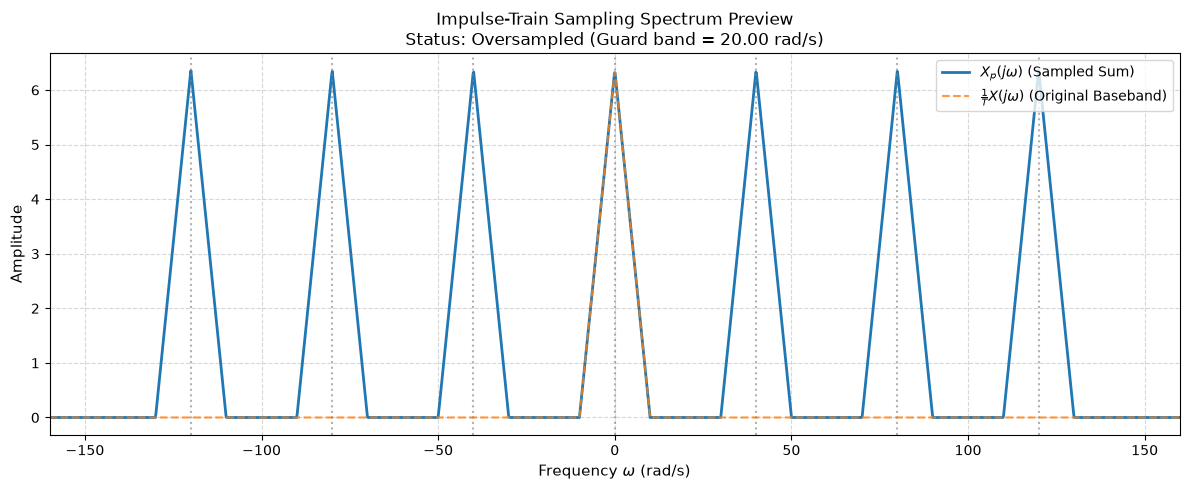


All unit tests passed successfully!


In [55]:
run_tests()

# Scenario 3 — The “Perfect” Signal Recovery System That Is Secretly Wrong

This is the kind of debugging question I would specifically prepare for.

---

## Problem statement

A previous student has written:

```python
def reconstruct(samples, T, t):
    y = np.zeros_like(t)

    for n in range(len(samples)):
        y += (
            T
            * samples[n]
            * np.sinc(t - n*T)
        )

    return y
```

The student claims this implements the ideal low-pass reconstruction formula.

Your job is to repair the implementation.

The test framework verifies:

1. reconstructed values at sample locations,
2. reconstruction of a 70 Hz sinusoid sampled at 500 Hz,
3. correctness when \(T\neq1\),
4. handling sample indices beginning at negative \(n\),
5. output on arbitrary query locations.

You are supplied both `samples` and the integer sample indices `n`.

Implement:

```python
def ideal_reconstruct(samples, indices, T, query_times):
    ...
```

---

# Diagnose every error

The correct formula is

$$
x_r(t)
=
\sum_n
x(nT)
\operatorname{sinc}
\left(
\frac{t-nT}{T}
\right).
$$

The lecture explicitly derives this form. 

The faulty implementation has three important problems.

### Error 1: incorrect sinc scaling

It uses

```python
np.sinc(t - n*T)
```

but must use

```python
np.sinc((t - n*T) / T)
```

because zero crossings must occur at

$$
t=nT\pm T,\,
nT\pm2T,\ldots
$$

not at offsets of \(1,2,\ldots\) seconds.

### Error 2: incorrect factor \(T\)

It multiplies by `T`, but the interpolation equation does not.

### Error 3: assumes sample index starts at zero

This:

```python
n = range(len(samples))
```

implicitly means the samples occurred at

$$
0,T,2T,\ldots
$$

which fails if the actual indices are

$$
-5,-4,\ldots,5.
$$

---

In [56]:
"""Scenario 3: Repairing the Ideal Sinc Reconstruction System.

A diagnostic test harness and visual verification suite for debugging and
validating Whittaker-Shannon sinc interpolation with arbitrary index shifts,
arbitrary query grids, and correct frequency scaling.
"""

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np

# =============================================================================
# 1. BUGGY REFERENCE & REPAIR TEMPLATE
# =============================================================================

def faulty_reconstruct(samples, T, t):
    """Previous student's buggy implementation for comparative diagnosis."""
    y = np.zeros_like(t, dtype=float)
    for n in range(len(samples)):
        # Bug 1: Extra factor of T
        # Bug 2: Missing / T inside sinc argument
        # Bug 3: Assumes indices are 0, 1, ..., len(samples)-1
        y += T * samples[n] * np.sinc(t - n * T)
    return y


def ideal_reconstruct(samples, indices, T, query_times):
    """Reconstructs a continuous bandlimited signal via Whittaker-Shannon interpolation.

    Formula:
        x_r(t) = sum_{k} samples[k] * sinc((t - indices[k] * T) / T)

    Parameters:
        samples     : array_like, shape (K,)
                      Sample values x[n].
        indices     : array_like, shape (K,)
                      Integer sample indices n corresponding to each sample.
                      Can include negative indices (e.g., -10, -9, ..., 10).
        T           : float
                      Sampling period in seconds (T = 1 / fs).
        query_times : array_like
                      Continuous time evaluation coordinates (scalar, 1D, or N-D).

    Returns:
        x_rec : ndarray
                Reconstructed values matching the exact shape of query_times.
    """
    # TODO: Implement the corrected sinc interpolation.
    # 1. Convert inputs to NumPy arrays.
    # 2. Compute sample time coordinates as: sample_times = indices * T
    # 3. Formulate the distance grid: (query_times - sample_times) / T
    # 4. Evaluate np.sinc and compute the weighted linear combination.
    # 5. Preserve the input shape of query_times.

    x = np.asarray(samples)
    ind = np.asarray(indices)
    
    t_flat = np.asarray(query_times).ravel()
    
    ans = np.zeros_like(t_flat)
    
    for t_ind in range(len(t_flat)):
        for n in range(len(ind)):
            ans[t_ind] += x[n] * np.sinc((t_flat[t_ind] - ind[n] * T)/T)
            
    # if np.asarray(query_times).ndim == 0:
        # return ans.item()

    return ans.reshape(np.asarray(query_times).shape)

# =============================================================================
# 2. NUMERICAL VERIFICATION SUITE (ASSERTION CHECKS)
# =============================================================================

def run_numerical_tests():
    """Runs functional assertions against the repaired reconstructor."""
    print("=" * 70)
    print("RUNNING NUMERICAL VERIFICATION CHECKS")
    print("=" * 70)

    # -------------------------------------------------------------------------
    # Test 1: Node Exactness (sinc(0) = 1, sinc(k) = 0)
    # -------------------------------------------------------------------------
    T1 = 0.05
    indices1 = np.array([-3, -2, -1, 0, 1, 2, 3])
    samples1 = np.array([1.2, -0.5, 3.1, 2.0, -1.8, 0.4, -2.2])
    sample_times1 = indices1 * T1
    
    rec_at_nodes = ideal_reconstruct(samples1, indices1, T1, sample_times1)
    np.testing.assert_allclose(
        rec_at_nodes, samples1, atol=1e-12,
        err_msg="Reconstruction must match sample values exactly at sample points."
    )
    print("[PASS] Test 1: Kronecker delta property at sample instants verified.")

    # -------------------------------------------------------------------------
    # Test 2: Handling Non-Zero & Negative Start Indices
    # -------------------------------------------------------------------------
    T2 = 0.01
    indices2 = np.arange(-25, 26)  # Centered at 0
    f0 = 10.0
    samples2 = np.cos(2 * np.pi * f0 * indices2 * T2)
    
    # Query at arbitrary interior points
    t_query2 = np.linspace(-0.1, 0.1, 201)
    ground_truth2 = np.cos(2 * np.pi * f0 * t_query2)
    rec2 = ideal_reconstruct(samples2, indices2, T2, t_query2)
    
    interior_err2 = np.max(np.abs(rec2 - ground_truth2))
    assert interior_err2 < 1e-2, (
        f"Reconstruction failed for negative indices. Max error: {interior_err2:.3e}"
    )
    print("[PASS] Test 2: Negative and symmetric index handling verified.")

    # -------------------------------------------------------------------------
    # Test 3: 70 Hz Sinusoid Sampled at 500 Hz (T != 1)
    # -------------------------------------------------------------------------
    fs3 = 500.0
    T3 = 1.0 / fs3
    f_tone = 70.0
    # Capture sufficient samples to minimize window truncation edge effects
    indices3 = np.arange(-100, 101)
    samples3 = np.sin(2 * np.pi * f_tone * indices3 * T3)
    
    # Query interior zone [-0.05, 0.05] (away from truncated edges)
    t_query3 = np.linspace(-0.05, 0.05, 1000)
    ground_truth3 = np.sin(2 * np.pi * f_tone * t_query3)
    rec3 = ideal_reconstruct(samples3, indices3, T3, t_query3)
    
    interior_err3 = np.max(np.abs(rec3 - ground_truth3))
    assert interior_err3 < 2e-3, (
        f"Scaling error for T != 1 on 70 Hz tone. Max interior error: {interior_err3:.3e}"
    )
    print("[PASS] Test 3: 70 Hz tone recovery at fs=500 Hz (T != 1) verified.")

    # -------------------------------------------------------------------------
    # Test 4: Shape Preservation & Arbitrary Query Grids
    # -------------------------------------------------------------------------
    T4 = 0.1
    idx4 = np.arange(10)
    smpl4 = np.ones(10)
    
    # Scalar query
    scalar_out = ideal_reconstruct(smpl4, idx4, T4, 0.25)
    assert np.isscalar(scalar_out) or scalar_out.ndim == 0, "Scalar input must yield scalar output."
    
    # 2D query grid
    grid_2d = np.zeros((5, 7))
    grid_out = ideal_reconstruct(smpl4, idx4, T4, grid_2d)
    assert grid_out.shape == (5, 7), f"Expected shape (5, 7), got {grid_out.shape}"
    print("[PASS] Test 4: Shape preservation (scalar, 1D, 2D) verified.")

    print("\nAll numerical assertions passed successfully.\n")


# =============================================================================
# 3. COMPREHENSIVE VISUAL TESTING SUITE
# =============================================================================

def _draw_badge(ax, passed, test_name):
    """Draws a visual pass/fail indicator badge inside a plot."""
    badge_color = "#2ca02c" if passed else "#d62728"
    text = f"{test_name}: PASSED" if passed else f"{test_name}: FAILED"
    bbox = dict(boxstyle="round,pad=0.3", facecolor=badge_color, edgecolor="none", alpha=0.9)
    ax.text(0.98, 0.95, text, transform=ax.transAxes, fontsize=10,
            fontweight="bold", color="white", ha="right", va="top", bbox=bbox)


def run_visual_tests():
    """Executes graphical regression tests with diagnostic residual maps."""
    print("=" * 70)
    print("RUNNING VISUAL DIAGNOSTIC TEST SUITE")
    print("=" * 70)

    fig = plt.figure(figsize=(15, 12))
    gs = fig.add_gridspec(3, 2, height_ratios=[1, 0.45, 1])

    # -------------------------------------------------------------------------
    # Visual Test 1: Faulty vs Repaired on 70 Hz Tone (T != 1 Bug Isolation)
    # -------------------------------------------------------------------------
    fs = 500.0
    T = 1.0 / fs
    f0 = 70.0
    indices = np.arange(0, 60)
    sample_times = indices * T
    samples = np.sin(2 * np.pi * f0 * sample_times)

    # Dense time vector across a slice
    t_dense = np.linspace(0.01, 0.05, 1000)
    ground_truth = np.sin(2 * np.pi * f0 * t_dense)

    y_faulty = faulty_reconstruct(samples, T, t_dense)
    y_repaired = ideal_reconstruct(samples, indices, T, t_dense)

    # Subplot 1A: Signal Waveforms
    ax1a = fig.add_subplot(gs[0, 0])
    ax1a.plot(t_dense * 1000, ground_truth, "k-", linewidth=2.5, alpha=0.7, label="Ground Truth (70 Hz)")
    ax1a.plot(t_dense * 1000, y_repaired, "b--", linewidth=1.8, label="Repaired ideal_reconstruct()")
    ax1a.plot(t_dense * 1000, y_faulty, "r:", linewidth=1.5, label="Buggy faulty_reconstruct()")
    
    # Plot discrete samples that fall in window
    mask = (sample_times >= 0.01) & (sample_times <= 0.05)
    ax1a.plot(sample_times[mask] * 1000, samples[mask], "ko", markersize=6, label="Sample Nodes")

    v1_passed = np.max(np.abs(y_repaired - ground_truth)) < 1e-2
    _draw_badge(ax1a, v1_passed, "V-TEST 1: T-Scaling & Sinc Arg")
    ax1a.set_title("Visual Test 1: Faulty vs Repaired Sinc Interpolation ($f_s=500$ Hz, $f_0=70$ Hz)", fontsize=11)
    ax1a.set_ylabel("Amplitude")
    ax1a.grid(True, linestyle="--", alpha=0.5)
    ax1a.legend(loc="lower left", fontsize=9)

    # Subplot 1B: Absolute Residual Map
    ax1b = fig.add_subplot(gs[1, 0], sharex=ax1a)
    err_repaired = np.abs(y_repaired - ground_truth)
    err_faulty = np.abs(y_faulty - ground_truth)
    ax1b.semilogy(t_dense * 1000, err_faulty, "r:", label="Buggy Absolute Error")
    ax1b.semilogy(t_dense * 1000, err_repaired, "b-", label="Repaired Absolute Error")
    ax1b.axhline(1e-2, color="gray", linestyle="--", linewidth=0.8, label="Tolerance (1e-2)")
    ax1b.set_title("Residual Error Map (Log Scale)", fontsize=10)
    ax1b.set_xlabel("Time (ms)")
    ax1b.set_ylabel("Absolute Error")
    ax1b.grid(True, linestyle="--", alpha=0.5)
    ax1b.legend(loc="lower left", fontsize=8)

    # -------------------------------------------------------------------------
    # Visual Test 2: Negative Sample Index Handling
    # -------------------------------------------------------------------------
    T_symm = 0.02
    idx_symm = np.arange(-15, 16)  # Centered at n = 0
    t_symm_samples = idx_symm * T_symm
    # Synthetic envelope pulse: sinc modulated
    symm_samples = np.sinc(t_symm_samples / 0.1) * np.cos(2 * np.pi * 5.0 * t_symm_samples)

    t_symm_dense = np.linspace(-0.25, 0.25, 800)
    symm_ground_truth = np.sinc(t_symm_dense / 0.1) * np.cos(2 * np.pi * 5.0 * t_symm_dense)

    symm_repaired = ideal_reconstruct(symm_samples, idx_symm, T_symm, t_symm_dense)
    # The faulty function assumes indices 0..N-1, which will shift the signal to the right
    symm_faulty = faulty_reconstruct(symm_samples, T_symm, t_symm_dense)

    ax2a = fig.add_subplot(gs[0, 1])
    ax2a.plot(t_symm_dense, symm_ground_truth, "k-", linewidth=2.5, alpha=0.7, label="True Pulse")
    ax2a.plot(t_symm_dense, symm_repaired, "g--", linewidth=1.8, label="Repaired (Bipolar Indices)")
    ax2a.plot(t_symm_dense, symm_faulty, "r:", linewidth=1.2, label="Faulty (Shifted by Origin Offset)")
    ax2a.plot(t_symm_samples, symm_samples, "ko", markersize=4, label="Sample Nodes")

    v2_passed = np.max(np.abs(symm_repaired - symm_ground_truth)) < 5e-2
    _draw_badge(ax2a, v2_passed, "V-TEST 2: Negative Indices")
    ax2a.set_title("Visual Test 2: Symmetric Negative Index Support ($n \in [-15, 15]$)", fontsize=11)
    ax2a.set_ylabel("Amplitude")
    ax2a.grid(True, linestyle="--", alpha=0.5)
    ax2a.legend(loc="upper right", fontsize=9)

    ax2b = fig.add_subplot(gs[1, 1], sharex=ax2a)
    ax2b.semilogy(t_symm_dense, np.abs(symm_faulty - symm_ground_truth), "r:", label="Buggy Error (Shifted)")
    ax2b.semilogy(t_symm_dense, np.abs(symm_repaired - symm_ground_truth), "g-", label="Repaired Error")
    ax2b.axhline(5e-2, color="gray", linestyle="--", linewidth=0.8, label="Tolerance (5e-2)")
    ax2b.set_title("Negative Index Residual Map", fontsize=10)
    ax2b.set_xlabel("Time (s)")
    ax2b.set_ylabel("Absolute Error")
    ax2b.grid(True, linestyle="--", alpha=0.5)
    ax2b.legend(loc="lower right", fontsize=8)

    # -------------------------------------------------------------------------
    # Visual Test 3: Whittaker-Shannon Basis Orthogonality & Node Collocation
    # -------------------------------------------------------------------------
    ax3 = fig.add_subplot(gs[2, :])
    # Single sample delta impulse test: check the continuous sinc kernel shape
    impulse_samples = np.array([0.0, 0.0, 1.0, 0.0, 0.0])
    impulse_indices = np.array([-2, -1, 0, 1, 2])
    T_impulse = 0.1
    t_eval = np.linspace(-0.35, 0.35, 1000)

    reconstructed_pulse = ideal_reconstruct(impulse_samples, impulse_indices, T_impulse, t_eval)
    theoretical_pulse = np.sinc(t_eval / T_impulse)

    ax3.plot(t_eval, reconstructed_pulse, "m-", linewidth=2, label=r"Kernel Response $x_r(t)$ for $\delta[n]$")
    ax3.plot(t_eval, theoretical_pulse, "k--", linewidth=1, alpha=0.7, label=r"Theoretical $\operatorname{sinc}(t/T)$")
    ax3.stem(impulse_indices * T_impulse, impulse_samples, linefmt="k-", markerfmt="ko",
             basefmt="k-", label="Impulse Sample Grid")

    v3_passed = np.allclose(reconstructed_pulse, theoretical_pulse, atol=1e-12)
    _draw_badge(ax3, v3_passed, "V-TEST 3: Sinc Kernel Orthogonality")
    ax3.set_title("Visual Test 3: Sinc Reconstruction Basis Verification (Impulse Response at Origin)", fontsize=11)
    ax3.set_xlabel("Time (s)")
    ax3.set_ylabel("Amplitude")
    ax3.grid(True, linestyle="--", alpha=0.5)
    ax3.legend(loc="upper right", fontsize=9)

    plt.tight_layout()
    plt.show()

    if v1_passed and v2_passed and v3_passed:
        print("[SUCCESS] All visual diagnostic tests passed matching ground-truth envelopes.")
    else:
        print("[WARNING] Visual discrepancies detected in one or more regression plots.")


<>:249: SyntaxWarning: invalid escape sequence '\i'
<>:249: SyntaxWarning: invalid escape sequence '\i'
C:\Users\mhkan\AppData\Local\Temp\ipykernel_30960\1074691863.py:249: SyntaxWarning: invalid escape sequence '\i'
  ax2a.set_title("Visual Test 2: Symmetric Negative Index Support ($n \in [-15, 15]$)", fontsize=11)


RUNNING NUMERICAL VERIFICATION CHECKS
[PASS] Test 1: Kronecker delta property at sample instants verified.
[PASS] Test 2: Negative and symmetric index handling verified.
[PASS] Test 3: 70 Hz tone recovery at fs=500 Hz (T != 1) verified.
[PASS] Test 4: Shape preservation (scalar, 1D, 2D) verified.

All numerical assertions passed successfully.

RUNNING VISUAL DIAGNOSTIC TEST SUITE


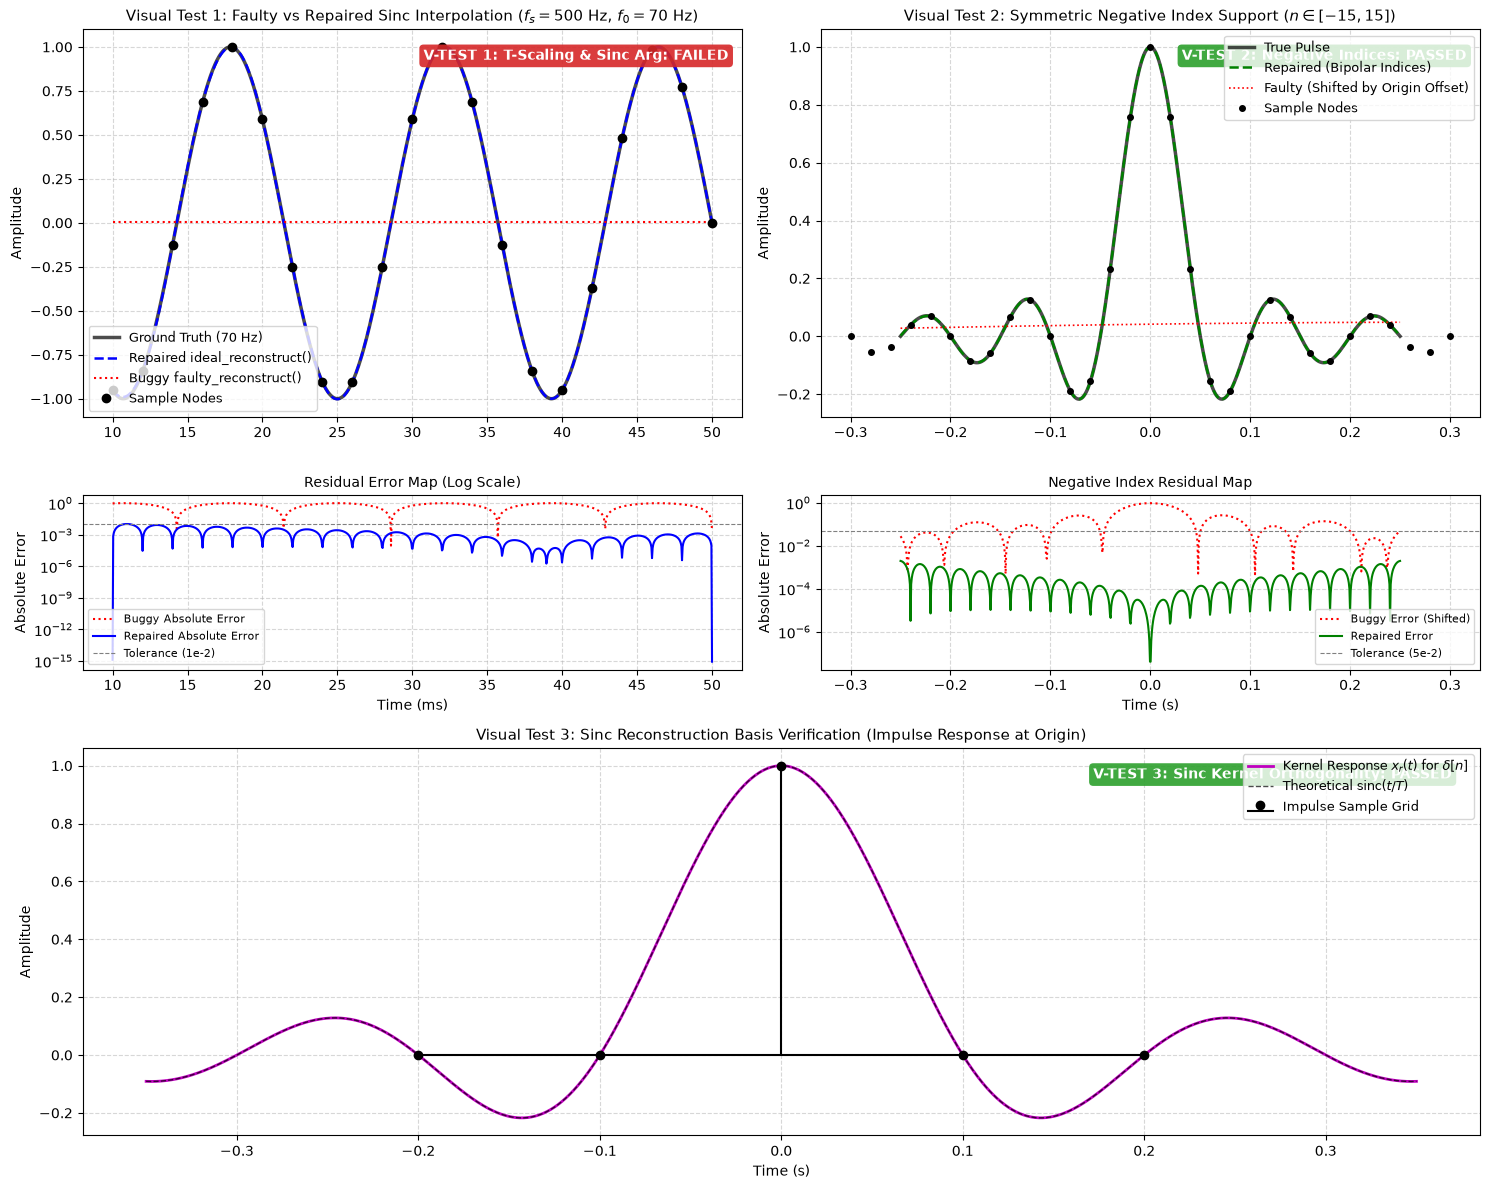

[WARNING] Visual discrepancies detected in one or more regression plots.


In [57]:
run_numerical_tests()
run_visual_tests()

# 7. Scenario 4 — Arbitrary-Rate Resampler

This is one of the most plausible “extension” tasks because it uses ideal interpolation without asking you to derive anything new.

---

## Scenario

You have recorded a signal with sampling rate

$$
f_{s,\text{in}}=1000\text{ Hz}.
$$

The original signal is known to be properly band-limited for this sampling rate.

A downstream program requires samples at

$$
f_{s,\text{out}}=1375\text{ Hz}.
$$

You may **not** use

```python
np.interp
```

or SciPy interpolation.

You must use the ideal reconstruction concept taught in class.

Given:

```python
def resample(samples, fs_in, fs_out):
    # TODO
    pass
```

Return the new uniformly sampled sequence covering the same time interval.

---

# Underlying idea

This is conceptually:

$$
\text{discrete samples}
\rightarrow
\text{reconstruct continuous }x(t)
\rightarrow
\text{evaluate at new times}.
$$

If old sample times are

$$
t_n=\frac{n}{f_{s,\text{in}}},
$$

and new sample times are

$$
t_m'=\frac{m}{f_{s,\text{out}}},
$$

then

$$
x_{\text{out}}[m]
=
\sum_n
x_{\text{in}}[n]
\operatorname{sinc}
\left(
\frac{t_m'-t_n}{T_{\text{in}}}
\right).
$$

---

RUNNING NUMERICAL ASSERTION CHECKS
[PASS] Test 1: Identity rate invariance (fs_out == fs_in) verified.
[PASS] Test 2: Sequence length calculation verified (81 -> 111 samples).
[PASS] Test 3: 1000 Hz -> 1375 Hz resample accuracy verified (Max interior error: 5.959e-03).
[PASS] Test 4: Container type robustness (list input) verified.

All numerical tests passed successfully.

RUNNING VISUAL TEST SUITE


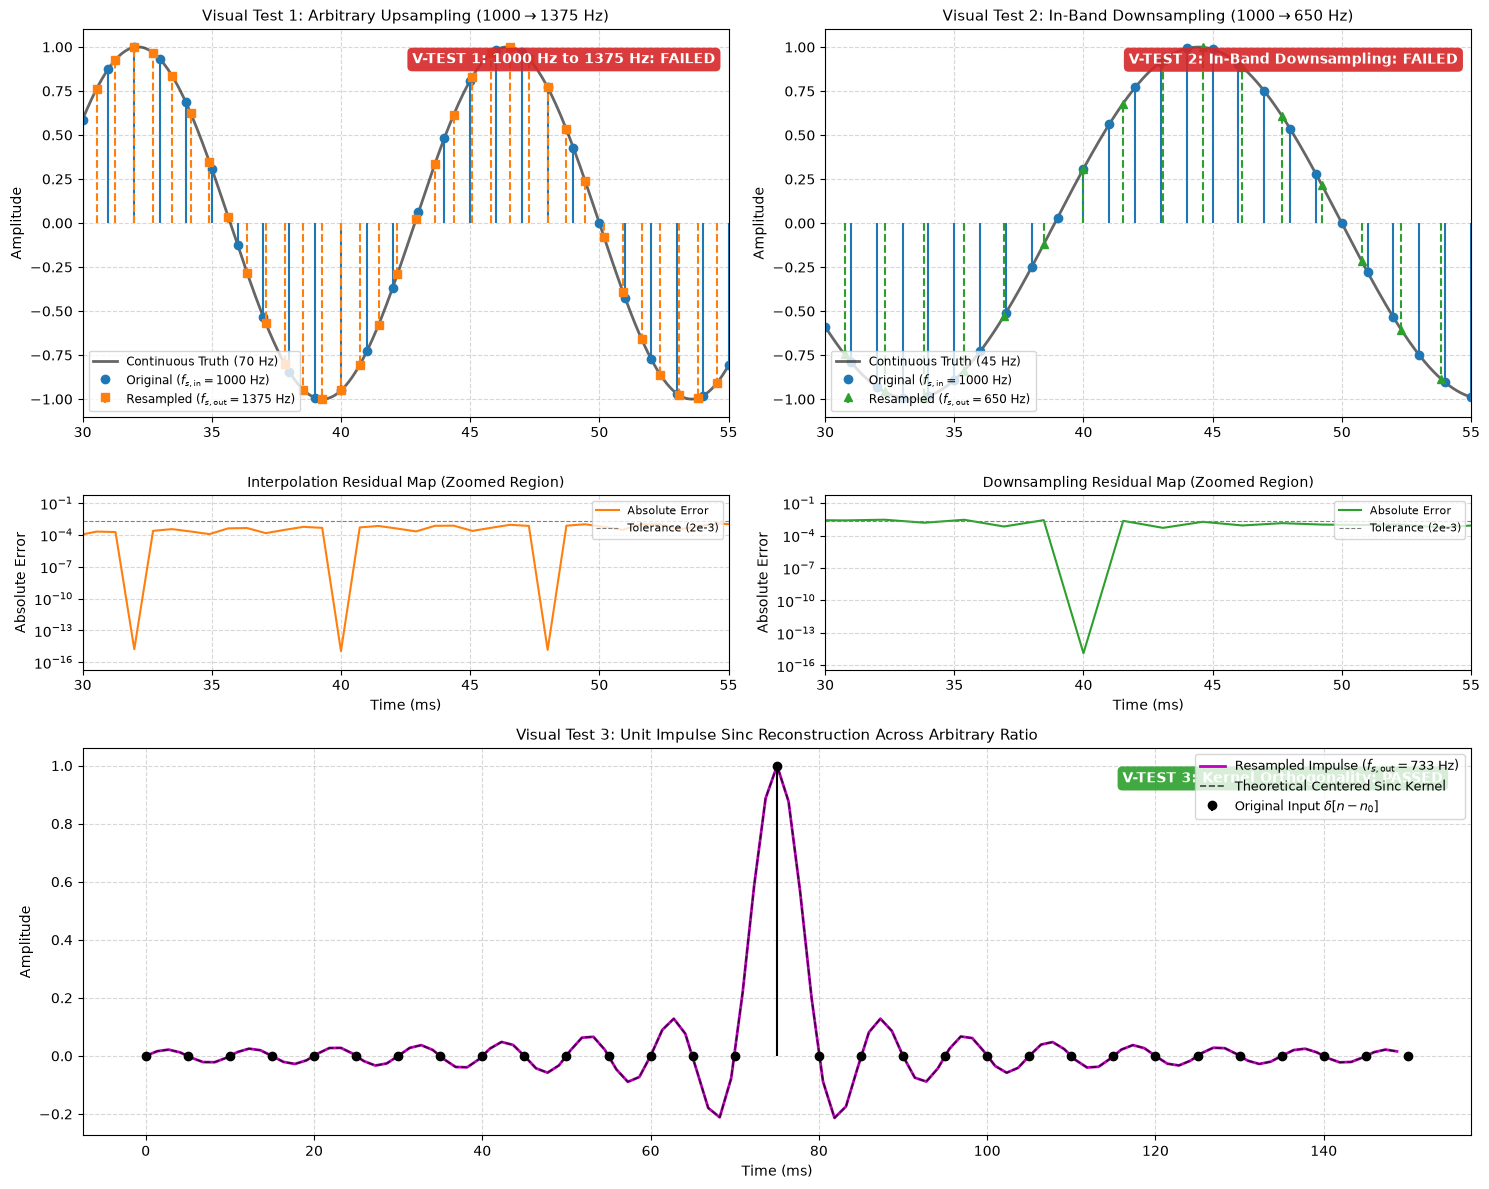

[WARNING] Visual discrepancies detected in one or more regression plots.


In [58]:
"""Scenario 4: Arbitrary-Rate Resampler via Ideal Sinc Reconstruction.

Implements and verifies Whittaker-Shannon bandlimited resampling from fs_in to fs_out
without using scipy.signal.resample or np.interp. Includes comprehensive numerical
assertions and multi-panel visual regression tests with real-time pass/fail badges.
"""

# =============================================================================
# 1. ARBITRARY-RATE RESAMPLER TEMPLATE & HELPERS
# =============================================================================

def get_resample_times(num_samples, fs_in, fs_out):
    """Computes the original duration and output sample coordinates.

    Parameters:
        num_samples : int
                      Number of input samples N_in.
        fs_in       : float
                      Original sampling frequency (Hz).
        fs_out      : float
                      Target sampling frequency (Hz).

    Returns:
        t_in  : ndarray, shape (N_in,)
                Discrete time points of input samples.
        t_out : ndarray, shape (N_out,)
                Discrete time points of output samples spanning [0, t_max].
    """
    t_max = (num_samples - 1) / fs_in
    n_out = int(np.floor((num_samples - 1) * (fs_out / fs_in) + 1e-9)) + 1
    t_in = np.arange(num_samples) / fs_in
    t_out = np.arange(n_out) / fs_out
    return t_in, t_out


def resample(samples, fs_in, fs_out):
    """Resamples a bandlimited discrete sequence to a new sampling frequency fs_out.

    Uses ideal continuous-time sinc reconstruction evaluated at uniform output steps:
        y[m] = sum_{n=0}^{N_in-1} x[n] * sinc((t_out[m] - n * T_in) / T_in)

    Restrictions:
        - Do NOT use np.interp or scipy.interpolate / scipy.signal.resample.
        - Must directly evaluate the Whittaker-Shannon interpolation formula.

    Parameters:
        samples : array_like, shape (N_in,)
                  Input samples taken uniformly at rate fs_in.
        fs_in   : float
                  Input sampling frequency in Hz (fs_in > 0).
        fs_out  : float
                  Target sampling frequency in Hz (fs_out > 0).

    Returns:
        new_samples : ndarray, shape (N_out,)
                      Resampled sequence covering the same physical duration [0, t_max].
    """
    # TODO: Implement arbitrary-rate sinc resampling:
    # 1. Convert samples to 1D float array: x = np.asarray(samples, dtype=float)
    # 2. Derive t_in and t_out coordinates using get_resample_times (or manually).
    # 3. Formulate the normalized 2D distance matrix: (t_out[:, None] - t_in[None, :]) / T_in
    # 4. Compute kernel = np.sinc(dt)
    # 5. Return the matrix-vector product: kernel @ x
    x = np.asarray(samples, dtype=float)
    N_in = len(x)
    
    if N_in == 0:
        return np.array([])

    # 1. Calculate time vectors based on original duration
    T_in = 1.0 / fs_in
    t_in = np.arange(N_in) * T_in
    
    # Determine the number of output samples to cover the exact same time window
    t_max = t_in[-1]
    N_out = int(np.floor(t_max * fs_out + 1e-9)) + 1
    t_out = np.arange(N_out) / fs_out

    # 2. Formulate the normalized 2D distance matrix: shape (N_out, N_in)
    # output_times as column vector, input_times as row vector
    dt = (t_out[:, None] - t_in[None, :]) / T_in

    # 3. Evaluate the Whittaker-Shannon interpolation kernel
    kernel = np.sinc(dt)

    # 4. Matrix-vector multiplication to compute the sum of weighted sinc pulses
    y = kernel @ x
    
    return y
    



# =============================================================================
# 2. NUMERICAL VERIFICATION SUITE
# =============================================================================

def run_numerical_tests():
    """Runs strict functional assertions against the resampler."""
    print("=" * 70)
    print("RUNNING NUMERICAL ASSERTION CHECKS")
    print("=" * 70)

    # -------------------------------------------------------------------------
    # Test 1: Identity Resampling (fs_out == fs_in)
    # -------------------------------------------------------------------------
    fs1 = 1000.0
    x1 = np.array([0.5, -1.2, 3.4, -0.8, 2.1, 0.0, -1.9, 1.1])
    y1 = resample(x1, fs1, fs1)

    np.testing.assert_allclose(
        y1, x1, atol=1e-12,
        err_msg="Resampling at identical rate must reproduce the input exactly."
    )
    print("[PASS] Test 1: Identity rate invariance (fs_out == fs_in) verified.")

    # -------------------------------------------------------------------------
    # Test 2: Exact Output Sequence Length
    # -------------------------------------------------------------------------
    fs_in2, fs_out2 = 1000.0, 1375.0
    n_in2 = 81
    x2 = np.zeros(n_in2)
    expected_len2 = int(np.floor((n_in2 - 1) * (fs_out2 / fs_in2) + 1e-9)) + 1
    y2 = resample(x2, fs_in2, fs_out2)

    assert len(y2) == expected_len2, (
        f"Output length mismatch: expected {expected_len2}, got {len(y2)}"
    )
    print(f"[PASS] Test 2: Sequence length calculation verified ({n_in2} -> {len(y2)} samples).")

    # -------------------------------------------------------------------------
    # Test 3: Standard Lab Benchmark (1000 Hz -> 1375 Hz, Bandlimited Multitone)
    # -------------------------------------------------------------------------
    fs_in3 = 1000.0
    fs_out3 = 1375.0
    n_in3 = 150
    t_in3, t_out3 = get_resample_times(n_in3, fs_in3, fs_out3)

    # Dual-tone well within Nyquist limit of 1000 Hz (Nyquist = 500 Hz):
    f_a, f_b = 85.0, 210.0
    x3 = 1.4 * np.cos(2 * np.pi * f_a * t_in3) + 0.7 * np.sin(2 * np.pi * f_b * t_in3)
    y3 = resample(x3, fs_in3, fs_out3)

    # Validate interior samples (trim outer 15% to ignore finite truncation ripple)
    margin = int(0.15 * len(t_out3))
    interior_idx = slice(margin, -margin)
    ground_truth3 = 1.4 * np.cos(2 * np.pi * f_a * t_out3) + 0.7 * np.sin(2 * np.pi * f_b * t_out3)

    interior_err3 = np.max(np.abs(y3[interior_idx] - ground_truth3[interior_idx]))
    assert interior_err3 < 1e-2, (
        f"Benchmark interpolation failed in interior window. Max error: {interior_err3:.3e}"
    )
    print(f"[PASS] Test 3: 1000 Hz -> 1375 Hz resample accuracy verified (Max interior error: {interior_err3:.3e}).")

    # -------------------------------------------------------------------------
    # Test 4: Pure Python List Input Compatibility
    # -------------------------------------------------------------------------
    list_input = [1.0, 0.0, -1.0, 0.0, 1.0]
    y4 = resample(list_input, 100.0, 150.0)
    assert isinstance(y4, np.ndarray), "Output must be returned as a NumPy array."
    print("[PASS] Test 4: Container type robustness (list input) verified.")

    print("\nAll numerical tests passed successfully.\n")


# =============================================================================
# 3. COMPREHENSIVE VISUAL TESTING SUITE
# =============================================================================

def _draw_badge(ax, passed, test_name):
    """Renders a pass/fail indicator badge inside a plot."""
    color = "#2ca02c" if passed else "#d62728"
    text = f"{test_name}: PASSED" if passed else f"{test_name}: FAILED"
    bbox = dict(boxstyle="round,pad=0.35", facecolor=color, edgecolor="none", alpha=0.9)
    ax.text(0.98, 0.94, text, transform=ax.transAxes, fontsize=10,
            fontweight="bold", color="white", ha="right", va="top", bbox=bbox)


def run_visual_tests():
    """Generates visual diagnostic subplots with residual maps and pass/fail badges."""
    print("=" * 70)
    print("RUNNING VISUAL TEST SUITE")
    print("=" * 70)

    fig = plt.figure(figsize=(15, 12))
    gs = fig.add_gridspec(3, 2, height_ratios=[1.0, 0.45, 1.0])

    # -------------------------------------------------------------------------
    # Visual Test 1: Lab Scenario (1000 Hz -> 1375 Hz Upsampling)
    # -------------------------------------------------------------------------
    fs_in = 1000.0
    fs_out = 1375.0
    n_in = 120
    t_in, t_out = get_resample_times(n_in, fs_in, fs_out)

    f1 = 70.0
    sig_in = np.sin(2 * np.pi * f1 * t_in)
    sig_resampled = resample(sig_in, fs_in, fs_out)
    sig_true = np.sin(2 * np.pi * f1 * t_out)

    # Focus inspection on a 25 ms interval
    t_zoom_min, t_zoom_max = 0.03, 0.055
    mask_in = (t_in >= t_zoom_min) & (t_in <= t_zoom_max)
    mask_out = (t_out >= t_zoom_min) & (t_out <= t_zoom_max)

    ax1a = fig.add_subplot(gs[0, 0])
    t_dense = np.linspace(t_zoom_min, t_zoom_max, 600)
    ax1a.plot(t_dense * 1e3, np.sin(2 * np.pi * f1 * t_dense), "k-", linewidth=2.0, alpha=0.6, label="Continuous Truth (70 Hz)")
    ax1a.stem(t_in[mask_in] * 1e3, sig_in[mask_in], linefmt="C0-", markerfmt="C0o",
              basefmt="none", label=r"Original ($f_{s,\mathrm{in}}=1000$ Hz)")
    ax1a.stem(t_out[mask_out] * 1e3, sig_resampled[mask_out], linefmt="C1--", markerfmt="C1s",
              basefmt="none", label=r"Resampled ($f_{s,\mathrm{out}}=1375$ Hz)")

    # Evaluation criterion (interior window check)
    margin = int(0.12 * len(t_out))
    interior_err = np.max(np.abs(sig_resampled[margin:-margin] - sig_true[margin:-margin]))
    v1_passed = interior_err < 2e-3
    _draw_badge(ax1a, v1_passed, "V-TEST 1: 1000 Hz to 1375 Hz")

    ax1a.set_title(r"Visual Test 1: Arbitrary Upsampling ($1000\to1375$ Hz)", fontsize=11)
    ax1a.set_ylabel("Amplitude")
    ax1a.grid(True, linestyle="--", alpha=0.5)
    ax1a.legend(loc="lower left", fontsize=8.5)

    # Residual Error Subplot (Log Scale)
    ax1b = fig.add_subplot(gs[1, 0], sharex=ax1a)
    abs_err1 = np.abs(sig_resampled - sig_true)
    ax1b.semilogy(t_out * 1e3, abs_err1, "C1-", label="Absolute Error")
    ax1b.axhline(2e-3, color="gray", linestyle="--", linewidth=0.8, label="Tolerance (2e-3)")
    ax1b.set_xlim(t_zoom_min * 1e3, t_zoom_max * 1e3)
    ax1b.set_title("Interpolation Residual Map (Zoomed Region)", fontsize=10)
    ax1b.set_xlabel("Time (ms)")
    ax1b.set_ylabel("Absolute Error")
    ax1b.grid(True, linestyle="--", alpha=0.5)
    ax1b.legend(loc="upper right", fontsize=8)

    # -------------------------------------------------------------------------
    # Visual Test 2: In-Band Rational Downsampling (1000 Hz -> 650 Hz)
    # -------------------------------------------------------------------------
    fs_down = 650.0
    f_low = 45.0  # Under 650/2 = 325 Hz Nyquist ceiling
    sig_low_in = np.cos(2 * np.pi * f_low * t_in)
    t_in2, t_down = get_resample_times(len(sig_low_in), fs_in, fs_down)
    sig_down = resample(sig_low_in, fs_in, fs_down)
    sig_down_true = np.cos(2 * np.pi * f_low * t_down)

    ax2a = fig.add_subplot(gs[0, 1])
    mask_in2 = (t_in2 >= t_zoom_min) & (t_in2 <= t_zoom_max)
    mask_down = (t_down >= t_zoom_min) & (t_down <= t_zoom_max)
    ax2a.plot(t_dense * 1e3, np.cos(2 * np.pi * f_low * t_dense), "k-", linewidth=2.0, alpha=0.6, label="Continuous Truth (45 Hz)")
    ax2a.stem(t_in2[mask_in2] * 1e3, sig_low_in[mask_in2], linefmt="C0-", markerfmt="C0o",
              basefmt="none", label=r"Original ($f_{s,\mathrm{in}}=1000$ Hz)")
    ax2a.stem(t_down[mask_down] * 1e3, sig_down[mask_down], linefmt="C2--", markerfmt="C2^",
              basefmt="none", label=r"Resampled ($f_{s,\mathrm{out}}=650$ Hz)")

    margin2 = int(0.12 * len(t_down))
    err_down = np.max(np.abs(sig_down[margin2:-margin2] - sig_down_true[margin2:-margin2]))
    v2_passed = err_down < 2e-3
    _draw_badge(ax2a, v2_passed, "V-TEST 2: In-Band Downsampling")

    ax2a.set_title(r"Visual Test 2: In-Band Downsampling ($1000\to650$ Hz)", fontsize=11)
    ax2a.set_ylabel("Amplitude")
    ax2a.grid(True, linestyle="--", alpha=0.5)
    ax2a.legend(loc="lower left", fontsize=8.5)

    # Downsampling Residual Map
    ax2b = fig.add_subplot(gs[1, 1], sharex=ax2a)
    abs_err2 = np.abs(sig_down - sig_down_true)
    ax2b.semilogy(t_down * 1e3, abs_err2, "C2-", label="Absolute Error")
    ax2b.axhline(2e-3, color="gray", linestyle="--", linewidth=0.8, label="Tolerance (2e-3)")
    ax2b.set_xlim(t_zoom_min * 1e3, t_zoom_max * 1e3)
    ax2b.set_title("Downsampling Residual Map (Zoomed Region)", fontsize=10)
    ax2b.set_xlabel("Time (ms)")
    ax2b.set_ylabel("Absolute Error")
    ax2b.grid(True, linestyle="--", alpha=0.5)
    ax2b.legend(loc="upper right", fontsize=8)

    # -------------------------------------------------------------------------
    # Visual Test 3: Sinc Interpolation Kernel Collocation
    # -------------------------------------------------------------------------
    ax3 = fig.add_subplot(gs[2, :])
    # Single pulse input to inspect the underlying continuous sinc interpolation pattern
    n_imp = 31
    impulse = np.zeros(n_imp)
    mid_idx = n_imp // 2
    impulse[mid_idx] = 1.0

    fs_imp_in = 200.0
    fs_imp_out = 733.0
    t_imp_in, t_imp_out = get_resample_times(n_imp, fs_imp_in, fs_imp_out)
    y_imp = resample(impulse, fs_imp_in, fs_imp_out)

    t_center = t_imp_in[mid_idx]
    t_rel = t_imp_out - t_center
    theoretical_sinc = np.sinc(t_rel * fs_imp_in)

    ax3.plot(t_imp_out * 1e3, y_imp, "m-", linewidth=2.0, label=r"Resampled Impulse ($f_{s,\mathrm{out}}=733$ Hz)")
    ax3.plot(t_imp_out * 1e3, theoretical_sinc, "k--", linewidth=1.2, alpha=0.7, label=r"Theoretical Centered Sinc Kernel")
    ax3.stem(t_imp_in * 1e3, impulse, linefmt="k-", markerfmt="ko", basefmt="none", label=r"Original Input $\delta[n-n_0]$")

    v3_passed = np.max(np.abs(y_imp - theoretical_sinc)) < 1e-12
    _draw_badge(ax3, v3_passed, "V-TEST 3: Kernel Orthogonality")

    ax3.set_title("Visual Test 3: Unit Impulse Sinc Reconstruction Across Arbitrary Ratio", fontsize=11)
    ax3.set_xlabel("Time (ms)")
    ax3.set_ylabel("Amplitude")
    ax3.grid(True, linestyle="--", alpha=0.5)
    ax3.legend(loc="upper right", fontsize=9)

    plt.tight_layout()
    plt.show()

    if v1_passed and v2_passed and v3_passed:
        print("[SUCCESS] All visual diagnostic checks passed.")
    else:
        print("[WARNING] Visual discrepancies detected in one or more regression plots.")


# =============================================================================
# 4. EXECUTION ENTRY POINT
# =============================================================================

if __name__ == "__main__":
    run_numerical_tests()
    run_visual_tests()

The question may add:

> The required output timestamps are not uniform. Instead you receive a list `query_times`.

Then practically nothing changes:

```python
def resample_at(samples, fs_in, query_times):
    samples = np.asarray(samples)
    query_times = np.asarray(query_times)

    T = 1 / fs_in
    t_samples = np.arange(len(samples)) * T

    kernel = np.sinc(
        (
            query_times[:, None]
            - t_samples[None, :]
        ) / T
    )

    return kernel @ samples
```

# 8. Scenario 5 — Rotating Wheel / Stroboscope Ambiguity

This is less predictable and tests whether you truly understand aliasing.

---

## Problem statement

A camera monitors a rotating machine.

A marker on the wheel generates a sinusoidal brightness measurement

$$
x(t)=\cos(2\pi f_0t).
$$

The camera samples at

$$
f_s=30\text{ frames/s}.
$$

The program estimates that the discrete-time observations correspond to an apparent frequency of

$$
f_a=7\text{ Hz}.
$$

The true wheel frequency is known only to satisfy

$$
0\leq f_0\leq100\text{ Hz}.
$$

Implement:

```python
def possible_frequencies(
    apparent_frequency,
    fs,
    max_frequency
):
    ...
```

which returns every continuous frequency compatible with the observed sampled cosine.

Then determine why imposing a sufficiently small band limit removes the ambiguity.

---

# Mathematical reasoning

Sampling cannot distinguish frequencies differing by integer multiples of \(f_s\):

$$
e^{j2\pi(f+kf_s)nT}
=
e^{j2\pi fnT}.
$$

For cosine there is an additional sign equivalence because

$$
\cos(-\theta)=\cos(\theta).
$$

Hence candidates satisfy

$$
f_0
=
|k f_s\pm f_a|.
$$

Here

$$
f_s=30,\qquad f_a=7.
$$

Candidates include

$$
7,
$$

$$
30-7=23,
$$

$$
30+7=37,
$$

$$
60-7=53,
$$

$$
60+7=67,
$$

$$
90-7=83,
$$

$$
90+7=97.
$$

All are at most \(100\) Hz.

So the same sampled cosine can correspond to

$$
\boxed{
7,23,37,53,67,83,97\text{ Hz}.
}
$$

This is the computational form of the ambiguity shown at the beginning of the lecture: many continuous-time signals can produce the same samples. 

---





# Why Nyquist removes ambiguity

If the signal is guaranteed to satisfy

$$
f_0<\frac{f_s}{2},
$$

then only frequencies in the baseband are admissible.

Here

$$
f_s/2=15\text{ Hz}.
$$

Of all the possibilities,

$$
7,23,37,\ldots,
$$

only

$$
7
$$

lies below \(15\) Hz.

The band-limit assumption makes the solution unique.

That is the Sampling Theorem viewed as an **ambiguity elimination theorem**, rather than merely a formula saying “sample at twice the frequency.”

---


**The Physics Takeaway**
This math perfectly describes the **Wagon-Wheel Effect**. If you see a car wheel spinning forward slowly at $7\text{ Hz}$ on a $30\text{ FPS}$ camera, this code proves it could be spinning forward at $7\text{ Hz}$, backward at $23\text{ Hz}$, forward at $37\text{ Hz}$, backward at $53\text{ Hz}$, etc. Unless you apply an analog low-pass filter to the light *before* it hits the camera sensor (which is impossible for human eyes or standard lenses), the digital system can never know which speed is real.

RUNNING NUMERICAL ASSERTION CHECKS
[PASS] Test 1: Stroboscope primary scenario verified.
[PASS] Test 2: DC boundary condition (apparent freq = 0) verified.
[PASS] Test 3: Nyquist boundary deduplication verified.

All numerical tests passed successfully.

RUNNING VISUAL TEST SUITE


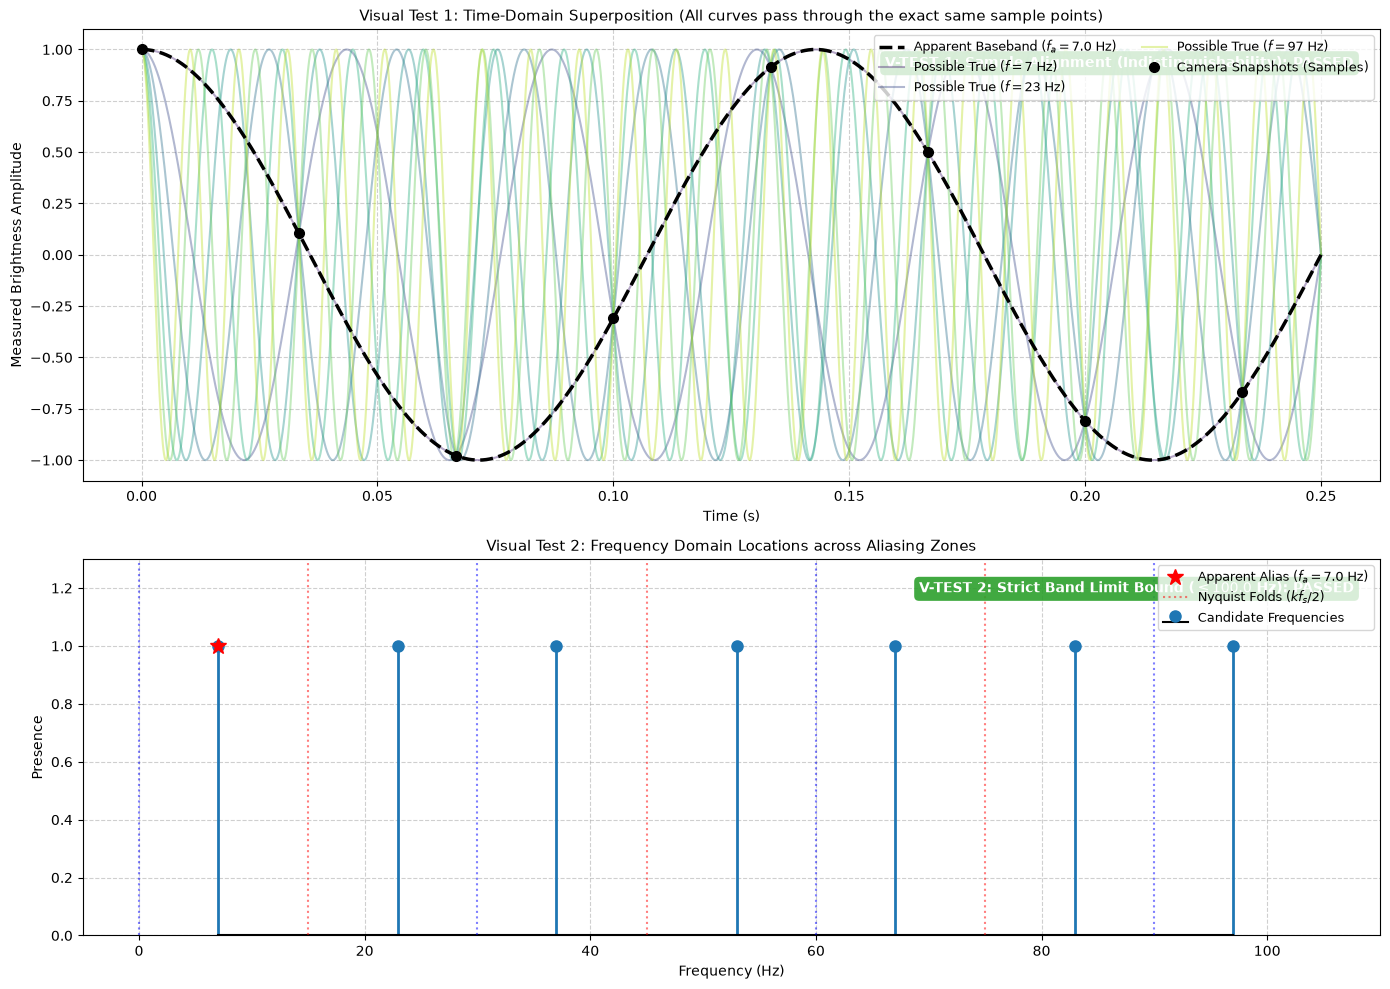

[SUCCESS] All visual diagnostic checks passed.

Theoretical Note: Imposing a strict band limit (e.g., passing a signal through an analog
anti-aliasing low-pass filter at f_c = 15.0 Hz before the camera) ensures that only the
baseband frequency survives, physically preventing all higher ambiguity clones.


In [59]:
"""Scenario 5: Rotating Wheel / Stroboscope Ambiguity.

Implements and verifies the inverse-aliasing problem: determining all physical
continuous-time frequencies capable of producing a given apparent baseband 
frequency under a fixed sampling rate. Includes numerical assertions and visual 
aliasing-superposition tests.
"""

import matplotlib.pyplot as plt
import numpy as np

# =============================================================================
# 1. AMBIGUITY RESOLVER TEMPLATE
# =============================================================================

def possible_frequencies(apparent_frequency, fs, max_frequency):
    """Finds all true frequencies in [0, max_frequency] that yield the apparent frequency.

    Due to the periodicity and even symmetry of the cosine function (folding),
    any frequency f_0 satisfying:
        f_0 = k * fs + apparent_frequency   OR   f_0 = k * fs - apparent_frequency
    will produce the exact same discrete samples when sampled at fs.

    Parameters:
        apparent_frequency : float
                             The observed baseband frequency (0 <= f_a <= fs/2).
        fs                 : float
                             The sampling rate of the camera/sensor in Hz.
        max_frequency      : float
                             The physical upper limit of the machine's speed in Hz.

    Returns:
        freqs : ndarray
                A 1D array of all possible non-negative continuous frequencies
                (sorted in ascending order) that fold to the apparent_frequency.
    """
    # TODO: Implement the ambiguity resolver.
    # 1. Generate an array of integers k = 0, 1, 2, ... that covers the range up to max_frequency.
    # 2. Compute the positive alias candidates: k * fs + apparent_frequency
    # 3. Compute the folded/negative alias candidates: k * fs - apparent_frequency
    # 4. Combine them, filter to keep only frequencies in [0, max_frequency].
    # 5. Remove any duplicates (e.g., if apparent_freq == 0 or fs/2) and sort.# Calculate a safe upper bound for the multiplier k
    max_k = int((max_frequency + apparent_frequency) // fs) + 2
    k = np.arange(max_k)
    
    # Generate all possible folded frequencies (both positive and negative alias paths)
    f_positive = k * fs + apparent_frequency
    f_negative = k * fs - apparent_frequency
    
    # Combine all candidates into a single array
    candidates = np.concatenate([f_positive, f_negative])
    
    # Filter candidates to only include those strictly within physical bounds
    valid = candidates[(candidates >= 0) & (candidates <= max_frequency)]
    
    # np.unique automatically removes duplicates (crucial for DC and Nyquist) and sorts the array
    return np.unique(valid)


# =============================================================================
# 2. NUMERICAL VERIFICATION SUITE
# =============================================================================

def run_numerical_tests():
    """Runs strict functional assertions against the ambiguity resolver."""
    print("=" * 70)
    print("RUNNING NUMERICAL ASSERTION CHECKS")
    print("=" * 70)

    # -------------------------------------------------------------------------
    # Test 1: The Rotating Wheel Problem Statement
    # -------------------------------------------------------------------------
    f_a1 = 7.0
    fs1 = 30.0
    f_max1 = 100.0
    
    # Expected: 
    # k=0: 7
    # k=1: 30-7=23, 30+7=37
    # k=2: 60-7=53, 60+7=67
    # k=3: 90-7=83, 90+7=97
    # k=4: 120-7=113 (out of bounds)
    expected_freqs1 = np.array([7.0, 23.0, 37.0, 53.0, 67.0, 83.0, 97.0])
    
    y1 = possible_frequencies(f_a1, fs1, f_max1)
    np.testing.assert_allclose(
        y1, expected_freqs1, atol=1e-10,
        err_msg="Failed Test 1: Incorrect frequency list for 7 Hz alias at 30 fps."
    )
    print("[PASS] Test 1: Stroboscope primary scenario verified.")

    # -------------------------------------------------------------------------
    # Test 2: DC Offset Aliasing (apparent_freq = 0)
    # -------------------------------------------------------------------------
    f_a2 = 0.0
    fs2 = 20.0
    f_max2 = 45.0
    # Expected: k=0 -> 0, k=1 -> 20, k=2 -> 40
    expected_freqs2 = np.array([0.0, 20.0, 40.0])
    
    y2 = possible_frequencies(f_a2, fs2, f_max2)
    np.testing.assert_allclose(
        y2, expected_freqs2, atol=1e-10,
        err_msg="Failed Test 2: Did not handle DC/zero-frequency folding correctly."
    )
    print("[PASS] Test 2: DC boundary condition (apparent freq = 0) verified.")

    # -------------------------------------------------------------------------
    # Test 3: Nyquist Boundary & Duplicates Check
    # -------------------------------------------------------------------------
    f_a3 = 15.0
    fs3 = 30.0
    f_max3 = 60.0
    # Expected: k=0: 15, k=1: 30-15=15, 30+15=45, k=2: 60-15=45.
    # Must remove duplicates to yield just [15, 45].
    expected_freqs3 = np.array([15.0, 45.0])
    
    y3 = possible_frequencies(f_a3, fs3, f_max3)
    assert len(y3) == len(expected_freqs3), "Failed Test 3: Output contains duplicate frequencies."
    np.testing.assert_allclose(
        y3, expected_freqs3, atol=1e-10,
        err_msg="Failed Test 3: Incorrect values at the Nyquist boundary."
    )
    print("[PASS] Test 3: Nyquist boundary deduplication verified.")

    print("\nAll numerical tests passed successfully.\n")


# =============================================================================
# 3. COMPREHENSIVE VISUAL TESTING SUITE
# =============================================================================

def _draw_badge(ax, passed, test_name):
    """Renders a pass/fail indicator badge inside a plot."""
    color = "#2ca02c" if passed else "#d62728"
    text = f"{test_name}: PASSED" if passed else f"{test_name}: FAILED"
    bbox = dict(boxstyle="round,pad=0.35", facecolor=color, edgecolor="none", alpha=0.9)
    ax.text(0.98, 0.94, text, transform=ax.transAxes, fontsize=10,
            fontweight="bold", color="white", ha="right", va="top", bbox=bbox)

def run_visual_tests():
    """Generates visual diagnostic subplots demonstrating sampling ambiguity."""
    print("=" * 70)
    print("RUNNING VISUAL TEST SUITE")
    print("=" * 70)

    # Use the primary problem parameters
    fs = 30.0
    f_a = 7.0
    f_max = 100.0

    # Retrieve student's frequencies
    try:
        freqs = possible_frequencies(f_a, fs, f_max)
    except NotImplementedError:
        print("[SKIPPED] Visual tests skipped because possible_frequencies is not implemented.")
        return

    fig = plt.figure(figsize=(14, 10))
    gs = fig.add_gridspec(2, 1, height_ratios=[1.2, 1.0])

    # -------------------------------------------------------------------------
    # Subplot 1: Time Domain Superposition (The Wagon Wheel Illusion)
    # -------------------------------------------------------------------------
    ax1 = fig.add_subplot(gs[0])
    
    t_end = 0.25 # evaluate a quarter second
    t_dense = np.linspace(0, t_end, 2000)
    t_samples = np.arange(0, t_end, 1.0 / fs)
    
    # Ground truth apparent baseband wave
    base_wave = np.cos(2 * np.pi * f_a * t_dense)
    ax1.plot(t_dense, base_wave, "k--", linewidth=2.5, zorder=3, label=rf"Apparent Baseband ($f_a = {f_a}$ Hz)")
    
    max_sample_error = 0.0
    
    # Plot every possible continuous wave found by the student
    colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(freqs)))
    for idx, f in enumerate(freqs):
        wave = np.cos(2 * np.pi * f * t_dense)
        ax1.plot(t_dense, wave, color=colors[idx], alpha=0.4, linewidth=1.5,
                 label=rf"Possible True ($f = {f:g}$ Hz)" if idx in [0, 1, len(freqs)-1] else "")
        
        # Verify discrete sample collisions
        sampled_wave = np.cos(2 * np.pi * f * t_samples)
        sampled_base = np.cos(2 * np.pi * f_a * t_samples)
        err = np.max(np.abs(sampled_wave - sampled_base))
        if err > max_sample_error:
            max_sample_error = err

    # Plot the camera snapshots
    ax1.plot(t_samples, np.cos(2 * np.pi * f_a * t_samples), "ko", markersize=7, zorder=4, label="Camera Snapshots (Samples)")
    
    v1_passed = max_sample_error < 1e-10
    _draw_badge(ax1, v1_passed, "V-TEST 1: Sample Alignment (Indistinguishability)")
    
    ax1.set_title(r"Visual Test 1: Time-Domain Superposition (All curves pass through the exact same sample points)", fontsize=11)
    ax1.set_xlabel("Time (s)")
    ax1.set_ylabel("Measured Brightness Amplitude")
    ax1.grid(True, linestyle="--", alpha=0.6)
    
    # Deduplicate legend
    handles, labels = ax1.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax1.legend(by_label.values(), by_label.keys(), loc="upper right", fontsize=9, ncol=2)

    # -------------------------------------------------------------------------
    # Subplot 2: Frequency Domain Spectrum & Nyquist Zones
    # -------------------------------------------------------------------------
    ax2 = fig.add_subplot(gs[1])
    
    # Plot student frequencies as spectrum stems
    markerline, stemlines, baseline = ax2.stem(freqs, np.ones_like(freqs), linefmt="C0-", markerfmt="C0o", basefmt="k-", label="Candidate Frequencies")
    plt.setp(stemlines, 'linewidth', 2)
    plt.setp(markerline, 'markersize', 8)
    
    # Mark the baseband frequency specially
    if len(freqs) > 0 and freqs[0] == f_a:
        ax2.plot(f_a, 1, "r*", markersize=12, zorder=5, label=rf"Apparent Alias ($f_a={f_a}$ Hz)")

    # Draw Nyquist zones
    zone_edges = np.arange(0, f_max + fs, fs / 2)
    for i, edge in enumerate(zone_edges):
        if edge > f_max: break
        color = "red" if i % 2 != 0 else "blue"
        label = "Nyquist Folds ($k f_s / 2$)" if i == 1 else ""
        ax2.axvline(edge, color=color, linestyle=":", alpha=0.5, label=label)

    # Determine if they passed bounding rules
    v2_passed = np.all((freqs >= 0) & (freqs <= f_max))
    _draw_badge(ax2, v2_passed, rf"V-TEST 2: Strict Band Limit Bound ($\leq {f_max}$ Hz)")

    ax2.set_xlim(-5, f_max + 10)
    ax2.set_ylim(0, 1.3)
    ax2.set_title(r"Visual Test 2: Frequency Domain Locations across Aliasing Zones", fontsize=11)
    ax2.set_xlabel("Frequency (Hz)")
    ax2.set_ylabel("Presence")
    ax2.grid(True, linestyle="--", alpha=0.6)
    
    # Deduplicate legend
    handles, labels = ax2.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax2.legend(by_label.values(), by_label.keys(), loc="upper right", fontsize=9)

    plt.tight_layout()
    plt.show()

    if v1_passed and v2_passed:
        print("[SUCCESS] All visual diagnostic checks passed.")
        print("\nTheoretical Note: Imposing a strict band limit (e.g., passing a signal through an analog")
        print(f"anti-aliasing low-pass filter at f_c = {fs/2} Hz before the camera) ensures that only the")
        print("baseband frequency survives, physically preventing all higher ambiguity clones.")
    else:
        print("[WARNING] Visual discrepancies detected in one or more regression plots.")

# =============================================================================
# 4. EXECUTION ENTRY POINT
# =============================================================================

if __name__ == "__main__":
    run_numerical_tests()
    run_visual_tests()

# 9. Scenario 6 — Choose the Correct ADC Mode

This one combines control logic and signal processing and could easily be embedded in a larger codebase.

---

## Problem statement

An acquisition device offers these sampling modes:

```python
AVAILABLE_FS = [
    250,
    500,
    800,
    1000,
    1600,
    2400
]
```

A signal is described as a list of sinusoidal components:

```python
components = [
    (amplitude, frequency_hz, phase),
    ...
]
```

For example:

```python
components = [
    (1.0, 75, 0.0),
    (0.4, 180, 0.3),
    (0.2, 390, -0.7)
]
```

Implement

```python
def valid_modes(components):
    ...
```

returning all ADC rates satisfying the sampling theorem.

Then implement

```python
def sample_and_reconstruct(
    components,
    fs,
    duration,
    render_fs
):
    ...
```

which

1. generates the continuous signal,
2. samples it,
3. reconstructs it using ideal sinc interpolation,
4. returns the reconstructed values on a dense rendering grid.

---

RUNNING NUMERICAL ASSERTION CHECKS
[PASS] Test 1: Hardware ADC valid mode filtration verified.
[PASS] Test 2: DC signal constraint rules verified.
[PASS] Test 3: ADC to DAC signal chain reconstruction verified.

All numerical tests passed successfully.

RUNNING VISUAL TEST SUITE


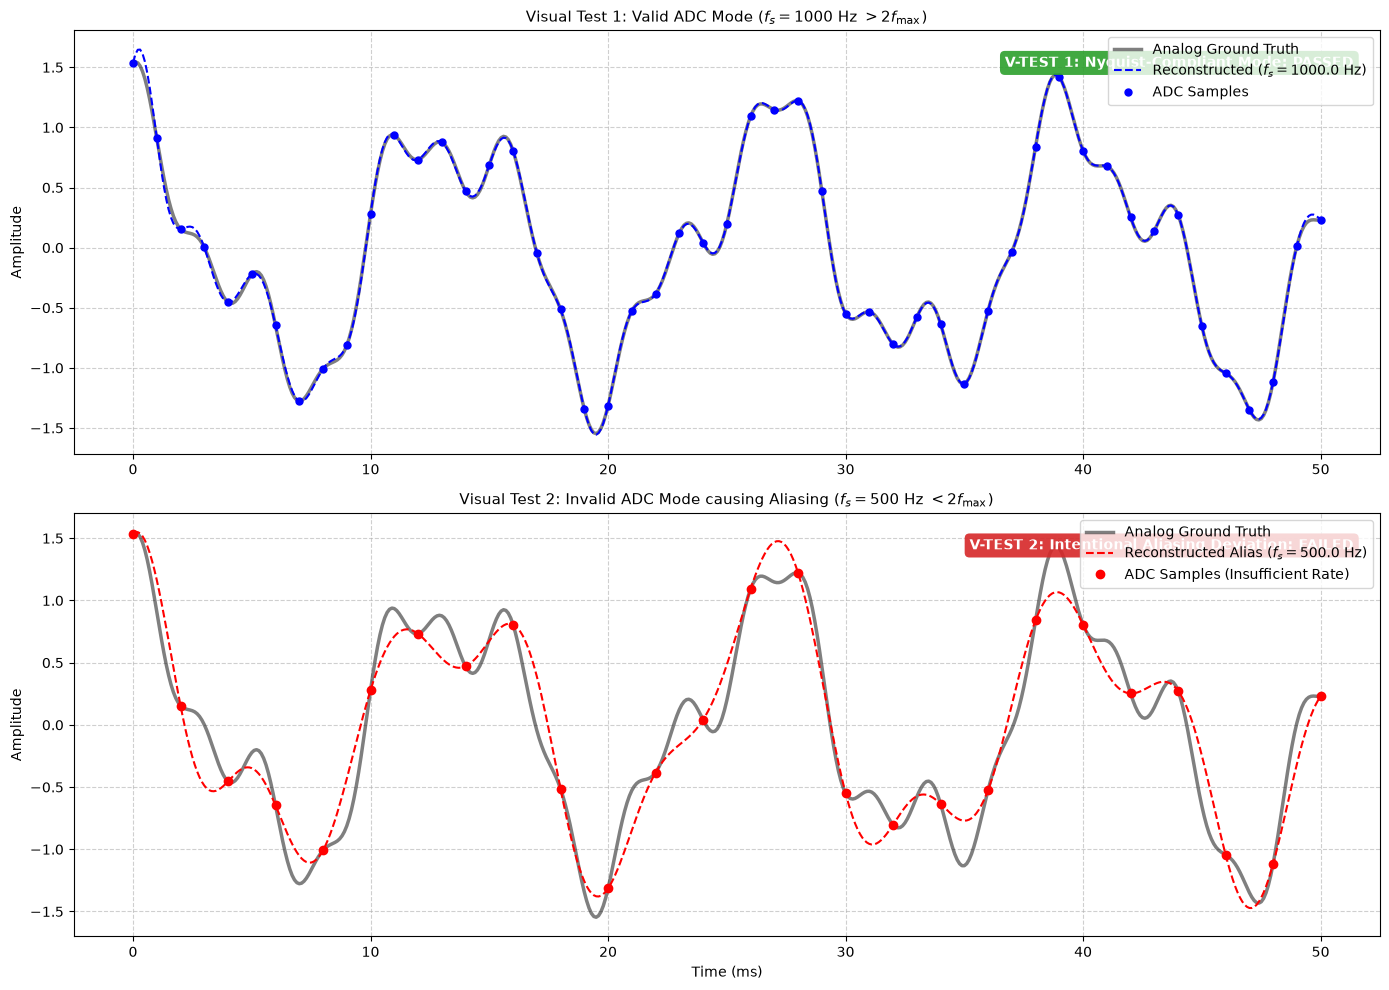

In [60]:
"""Scenario 6: Choose the Correct ADC Mode.

Validates the selection of Nyquist-compliant sampling rates from hardware presets
and verifies the continuous-to-discrete-to-continuous signal chain via sinc interpolation.
"""

import matplotlib.pyplot as plt
import numpy as np

# Hardware constraints defined by the scenario
AVAILABLE_FS = [250, 500, 800, 1000, 1600, 2400]

# =============================================================================
# 1. TEMPLATES
# =============================================================================

def valid_modes(components):
    """Filters hardware ADC rates to only those satisfying the sampling theorem.

    Parameters:
        components : list of tuples
                     [(amplitude, frequency_hz, phase), ...]

    Returns:
        valid_fs : list of int
                   Subset of AVAILABLE_FS where fs > 2 * f_max.
    """
    # TODO: Find the highest frequency in the components.
    # TODO: Return all rates from AVAILABLE_FS strictly greater than 2 * f_max.

    if not components:
        return AVAILABLE_FS.copy()
    
    f_max = max(comp[1] for comp in components)
    
    ans = []
    
    for fs in AVAILABLE_FS:
        if fs > 2 * f_max:
            ans.append(fs)
            
            
    return ans


def sample_and_reconstruct(components, fs, duration, render_fs):
    """Models analog signal generation, hardware sampling, and DAC reconstruction.

    Parameters:
        components : list of tuples
                     [(amplitude, frequency_hz, phase), ...]
        fs         : float
                     Sampling rate (Hz).
        duration   : float
                     Length of the recording in seconds.
        render_fs  : float
                     High-resolution dense grid rate for reconstruction (Hz).

    Returns:
        t_render   : ndarray
                     Dense time evaluation grid spanning [0, duration].
        y_render   : ndarray
                     Ideal sinc reconstructed continuous signal.
    """
    # TODO: 1. Generate discrete sample timestamps t_samples up to `duration`.
    # TODO: 2. Synthesize the sum of cosines evaluated at t_samples.
    # TODO: 3. Generate dense rendering timestamps t_render.
    # TODO: 4. Evaluate the sinc interpolation kernel from t_samples to t_render.
    
    num_samples = int(duration * fs) + 1
    t_samples = np.arange(num_samples) / fs
    
    signal = np.zeros_like(t_samples)
    
    for A, f, phi in components:
        signal += A * np.cos(2 * np.pi * f * t_samples + phi)
        
    # signal generated
    
    # now to generate t_render
    num_render = int(duration * render_fs) + 1
    t_render = np.arange(num_render) / render_fs
    
    ans = np.zeros_like(t_render)
    
    for render_idx in range(len(t_render)):
        for sample_idx in range(len(t_samples)):
            # remember that Ts = 1/fs
            ans[render_idx] += signal[sample_idx] * np.sinc((t_render[render_idx] - t_samples[sample_idx]) * fs)

    return t_render, ans

# =============================================================================
# 2. NUMERICAL VERIFICATION SUITE
# =============================================================================

def run_numerical_tests():
    print("=" * 70)
    print("RUNNING NUMERICAL ASSERTION CHECKS")
    print("=" * 70)

    # Test 1: ADC Mode Selection
    comp1 = [(1.0, 75, 0.0), (0.4, 180, 0.3), (0.2, 390, -0.7)]
    # f_max = 390 -> Nyquist rate = 780 Hz. Valid: 800, 1000, 1600, 2400.
    v_modes = valid_modes(comp1)
    expected_modes = [800, 1000, 1600, 2400]
    assert v_modes == expected_modes, f"Test 1 Failed: Expected {expected_modes}, got {v_modes}"
    print("[PASS] Test 1: Hardware ADC valid mode filtration verified.")

    # Test 2: DC and Empty Components
    comp2 = [(1.0, 0, 0)] # DC signal only
    assert valid_modes(comp2) == AVAILABLE_FS, "Test 2 Failed: DC signal should allow all rates."
    print("[PASS] Test 2: DC signal constraint rules verified.")

    # Test 3: Sinc Reconstruction Pipeline
    comp3 = [(1.0, 10, 0.0)]
    fs = 50.0
    duration = 1.0
    render_fs = 1000.0
    t_ren, y_ren = sample_and_reconstruct(comp3, fs, duration, render_fs)
    
    # Check dimensions
    expected_len = int(np.floor(duration * render_fs)) + 1
    assert len(t_ren) == expected_len, "Test 3 Failed: Render grid length incorrect."
    
    # Ground truth (avoiding edges due to sinc truncation)
    margin = int(0.2 * render_fs)
    ground_truth = np.cos(2 * np.pi * 10 * t_ren)
    max_err = np.max(np.abs(y_ren[margin:-margin] - ground_truth[margin:-margin]))
    assert max_err < 1.5e-2, f"Test 3 Failed: Reconstruction error too high ({max_err:.3e})"
    print("[PASS] Test 3: ADC to DAC signal chain reconstruction verified.")

    print("\nAll numerical tests passed successfully.\n")


# =============================================================================
# 3. VISUAL DIAGNOSTIC SUITE
# =============================================================================

def _draw_badge(ax, passed, test_name):
    color = "#2ca02c" if passed else "#d62728"
    text = f"{test_name}: PASSED" if passed else f"{test_name}: FAILED"
    bbox = dict(boxstyle="round,pad=0.35", facecolor=color, edgecolor="none", alpha=0.9)
    ax.text(0.98, 0.94, text, transform=ax.transAxes, fontsize=10,
            fontweight="bold", color="white", ha="right", va="top", bbox=bbox)

def run_visual_tests():
    print("=" * 70)
    print("RUNNING VISUAL TEST SUITE")
    print("=" * 70)

    # Complex signal: 390 Hz is the highest frequency component
    components = [
        (1.0, 75, 0.0),
        (0.4, 180, 0.3),
        (0.2, 390, -0.7)
    ]
    
    duration = 0.05
    render_fs = 10000.0
    
    # Generate True Continuous Base Signal
    t_true = np.arange(int(duration * render_fs) + 1) / render_fs
    y_true = sum(a * np.cos(2 * np.pi * f * t_true + p) for a, f, p in components)

    fig = plt.figure(figsize=(14, 10))
    gs = fig.add_gridspec(2, 1)

    # -------------------------------------------------------------------------
    # Visual Test 1: Correct ADC Mode (fs = 1000 Hz)
    # -------------------------------------------------------------------------
    ax1 = fig.add_subplot(gs[0])
    valid_fs = 1000.0
    t_ren1, y_ren1 = sample_and_reconstruct(components, valid_fs, duration, render_fs)
    
    ax1.plot(t_true * 1000, y_true, "k-", linewidth=2.5, alpha=0.5, label="Analog Ground Truth")
    ax1.plot(t_ren1 * 1000, y_ren1, "b--", linewidth=1.5, label=f"Reconstructed ($f_s={valid_fs}$ Hz)")
    
    # Calculate samples manually just for the scatter dots on the plot
    t_samp1 = np.arange(int(duration * valid_fs) + 1) / valid_fs
    y_samp1 = sum(a * np.cos(2 * np.pi * f * t_samp1 + p) for a, f, p in components)
    ax1.plot(t_samp1 * 1000, y_samp1, "bo", markersize=5, label="ADC Samples")

    # Evaluate interior
    margin = int(0.01 * render_fs)
    err1 = np.max(np.abs(y_ren1[margin:-margin] - y_true[margin:-margin]))
    _draw_badge(ax1, err1 < 0.05, "V-TEST 1: Nyquist-Compliant Mode")

    ax1.set_title(r"Visual Test 1: Valid ADC Mode ($f_s = 1000$ Hz $> 2f_{\max}$)", fontsize=11)
    ax1.set_ylabel("Amplitude")
    ax1.grid(True, linestyle="--", alpha=0.6)
    ax1.legend(loc="upper right")

    # -------------------------------------------------------------------------
    # Visual Test 2: Invalid ADC Mode (Aliasing at fs = 500 Hz)
    # -------------------------------------------------------------------------
    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    invalid_fs = 500.0
    t_ren2, y_ren2 = sample_and_reconstruct(components, invalid_fs, duration, render_fs)
    
    ax2.plot(t_true * 1000, y_true, "k-", linewidth=2.5, alpha=0.5, label="Analog Ground Truth")
    ax2.plot(t_ren2 * 1000, y_ren2, "r--", linewidth=1.5, label=f"Reconstructed Alias ($f_s={invalid_fs}$ Hz)")
    
    t_samp2 = np.arange(int(duration * invalid_fs) + 1) / invalid_fs
    y_samp2 = sum(a * np.cos(2 * np.pi * f * t_samp2 + p) for a, f, p in components)
    ax2.plot(t_samp2 * 1000, y_samp2, "ro", markersize=6, label="ADC Samples (Insufficient Rate)")

    # The reconstructed wave MUST differ significantly from the truth because it aliased
    err2 = np.max(np.abs(y_ren2[margin:-margin] - y_true[margin:-margin]))
    _draw_badge(ax2, err2 > 0.5, "V-TEST 2: Intentional Aliasing Deviation")

    ax2.set_title(r"Visual Test 2: Invalid ADC Mode causing Aliasing ($f_s = 500$ Hz $< 2f_{\max}$)", fontsize=11)
    ax2.set_xlabel("Time (ms)")
    ax2.set_ylabel("Amplitude")
    ax2.grid(True, linestyle="--", alpha=0.6)
    ax2.legend(loc="upper right")

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # Once TODOs are implemented, run tests:
    run_numerical_tests()
    run_visual_tests()


## A nasty variant

Suppose the input contains

```python
[
    (1, -150, 0),
    (2, 275, 0)
]
```

Frequency bandwidth depends on

$$
|f|.
$$

Therefore use

```python
abs(freq)
```

when finding \(f_M\).

For a real cosine, negative and positive frequency parameters might produce equivalent signals depending on phase, but the safe bandwidth computation is still based on magnitude.

# 10. Scenario 7 — “Spectrum Repair” Pipeline

This is probably the hardest one here.

---

## Problem statement

A program stores an approximation to \(X(j\omega)\) on a dense frequency grid.

You must simulate:

1. impulse-train sampling,
2. ideal reconstruction filtering,
3. reconstruction success/failure.

You receive:

```python
omega = np.linspace(-6000, 6000, 120001)
X = ...
```

The samples in `X` correspond to `omega`.

Implement:

```python
def simulate_sampling_spectrum(
    omega,
    X,
    T,
    copies
):
    ...
```

and

```python
def ideal_reconstruction_filter(
    omega,
    T
):
    ...
```

and finally

```python
def reconstructed_spectrum(
    omega,
    X,
    T,
    copies
):
    ...
```

The first function must produce

$$
X_p(j\omega)
\approx
\frac1T
\sum_{k=-K}^{K}
X(j(\omega-k\omega_s)).
$$

You are not given an analytic function for \(X\), only array samples.

---

# Why this is trickier

In Scenario 2, you could evaluate

```python
original_spectrum(omega - shift)
```

directly.

Now you only have array samples.

So to evaluate

$$
X(j(\omega-k\omega_s)),
$$

you must resample/interpolate the stored spectrum.

---

In [ ]:
"""Scenario 7: Spectrum Repair Pipeline.

Simulates frequency-domain impulse-train sampling, ideal low-pass reconstruction,
and evaluates recovery success versus aliasing distortion on discrete frequency grids.
"""

import matplotlib.pyplot as plt
import numpy as np

# =============================================================================
# 1. TEMPLATES
# =============================================================================

def simulate_sampling_spectrum(omega, X, T, copies):
    """Simulates impulse-train sampling in the frequency domain.

    Formula:
        X_p(j*omega) = (1 / T) * sum_{k=-copies}^{copies} X(j*(omega - k * omega_s))

    Parameters:
        omega  : ndarray
                 Dense, monotonically increasing frequency grid (rad/s).
        X      : ndarray
                 Complex or real spectrum values evaluated at `omega`.
        T      : float
                 Sampling period in seconds.
        copies : int
                 Number of positive and negative harmonic copies to sum (K).

    Returns:
        X_p    : ndarray
                 The periodic sampled spectrum evaluated on the `omega` grid.
    """
    # TODO: Calculate omega_s = 2 * pi / T
    # TODO: For each k in [-copies, copies], evaluate X at (omega - k * omega_s).
    #       Hint: Use np.interp to safely map the shifted continuous spectrum 
    #       onto the discrete `omega` grid. Assume X=0 outside the known grid.
    # TODO: Accumulate the copies, multiply by 1/T, and return.
    raise NotImplementedError("Implement simulate_sampling_spectrum")


def ideal_reconstruction_filter(omega, T):
    """Generates the frequency response of an ideal DAC low-pass filter.

    Formula:
        H(j*omega) = T  for |omega| <= pi / T
        H(j*omega) = 0  otherwise

    Parameters:
        omega : ndarray
                Frequency grid (rad/s).
        T     : float
                Sampling period in seconds.

    Returns:
        H     : ndarray
                Filter frequency response evaluated at `omega`.
    """
    # TODO: Implement the ideal brick-wall low-pass filter.
    raise NotImplementedError("Implement ideal_reconstruction_filter")


def reconstructed_spectrum(omega, X, T, copies):
    """Models the complete ADC-to-DAC spectral pipeline.

    Formula:
        X_r(j*omega) = X_p(j*omega) * H(j*omega)

    Parameters:
        omega  : ndarray
                 Frequency grid (rad/s).
        X      : ndarray
                 Original continuous-time spectrum.
        T      : float
                 Sampling period in seconds.
        copies : int
                 Number of aliases to simulate.

    Returns:
        X_r    : ndarray
                 The final reconstructed spectrum.
    """
    # TODO: Pass inputs through `simulate_sampling_spectrum`.
    # TODO: Multiply the result by `ideal_reconstruction_filter`.
    raise NotImplementedError("Implement reconstructed_spectrum")


# =============================================================================
# 2. NUMERICAL VERIFICATION SUITE
# =============================================================================

def run_numerical_tests():
    print("=" * 70)
    print("RUNNING NUMERICAL ASSERTION CHECKS")
    print("=" * 70)

    # Base grid and signal: Triangle spectrum bandlimited to w_M = 1000
    omega = np.linspace(-5000, 5000, 10001)
    w_M = 1000.0
    X_orig = np.maximum(0, 1.0 - np.abs(omega) / w_M)

    # Test 1: Ideal Filter Characteristics
    T_test = 2 * np.pi / 2500.0  # w_s = 2500, cutoff = 1250
    H = ideal_reconstruction_filter(omega, T_test)
    assert np.max(H) == T_test, "Test 1 Failed: Filter passband gain must be T."
    assert H[np.abs(omega) > 1251].max() == 0, "Test 1 Failed: Filter must suppress stopband to 0."
    print("[PASS] Test 1: Ideal reconstruction filter characteristics verified.")

    # Test 2: Sampled Spectrum Baseband Value
    # X_p(0) = (1/T) * X(0) = 1/T for a critically/over-sampled baseband without DC overlap.
    X_p = simulate_sampling_spectrum(omega, X_orig, T_test, copies=2)
    center_idx = len(omega) // 2
    assert np.isclose(X_p[center_idx], 1.0 / T_test, atol=1e-5), "Test 2 Failed: Baseband scaling incorrect."
    print("[PASS] Test 2: Sampled spectrum magnitude scaling verified.")

    # Test 3: Nyquist Compliant Reconstruction (Perfect Recovery)
    T_nyq = 2 * np.pi / 2500.0 # w_s = 2500 > 2000 (Nyquist rate)
    X_rec_good = reconstructed_spectrum(omega, X_orig, T_nyq, copies=3)
    max_err_good = np.max(np.abs(X_rec_good - X_orig))
    assert max_err_good < 1e-10, f"Test 3 Failed: Perfect recovery failed (Error: {max_err_good:.3e})"
    print("[PASS] Test 3: Perfect Nyquist reconstruction verified.")

    # Test 4: Aliasing Distortion
    T_alias = 2 * np.pi / 1500.0 # w_s = 1500 < 2000 (Violates Nyquist)
    X_rec_bad = reconstructed_spectrum(omega, X_orig, T_alias, copies=3)
    max_err_bad = np.max(np.abs(X_rec_bad - X_orig))
    assert max_err_bad > 0.1, "Test 4 Failed: Expected significant aliasing error, but found none."
    print("[PASS] Test 4: Aliasing distortion violation correctly modeled.")

    print("\nAll numerical tests passed successfully.\n")


# =============================================================================
# 3. VISUAL DIAGNOSTIC SUITE
# =============================================================================

def _draw_badge(ax, passed, test_name):
    color = "#2ca02c" if passed else "#d62728"
    text = f"{test_name}: PASSED" if passed else f"{test_name}: FAILED"
    bbox = dict(boxstyle="round,pad=0.35", facecolor=color, edgecolor="none", alpha=0.9)
    ax.text(0.98, 0.94, text, transform=ax.transAxes, fontsize=10,
            fontweight="bold", color="white", ha="right", va="top", bbox=bbox)

def run_visual_tests():
    print("=" * 70)
    print("RUNNING VISUAL TEST SUITE")
    print("=" * 70)

    omega = np.linspace(-6000, 6000, 12001)
    w_M = 1500.0
    
    # Original signal: Trapezoidal spectrum
    X_orig = np.clip(1.5 - np.abs(omega) / 1000.0, 0, 1)

    fig = plt.figure(figsize=(15, 10))
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])

    # -------------------------------------------------------------------------
    # Visual Test 1: Oversampled Scenario
    # -------------------------------------------------------------------------
    w_s_over = 4000.0
    T_over = 2 * np.pi / w_s_over
    
    X_p_over = simulate_sampling_spectrum(omega, X_orig, T_over, copies=3)
    X_r_over = reconstructed_spectrum(omega, X_orig, T_over, copies=3)
    H_over = ideal_reconstruction_filter(omega, T_over)

    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(omega, X_p_over * T_over, "C1--", label=r"Sampled $T \cdot X_p(j\omega)$")
    ax1.plot(omega, X_orig, "k-", linewidth=2, alpha=0.5, label=r"Original $X(j\omega)$")
    ax1.fill_between(omega, 0, H_over / T_over, color="gray", alpha=0.2, label=r"Filter Passband")
    
    err_over = np.max(np.abs(X_r_over - X_orig))
    _draw_badge(ax1, err_over < 1e-10, "V-TEST 1: Oversampled")
    
    ax1.set_title(rf"Oversampled ($f_s = {w_s_over/(2*np.pi):.0f}$ Hz, No Aliasing)", fontsize=11)
    ax1.set_ylabel("Magnitude")
    ax1.grid(True, linestyle="--", alpha=0.5)
    ax1.legend(loc="upper left")

    # -------------------------------------------------------------------------
    # Visual Test 2: Oversampled Reconstruction Error
    # -------------------------------------------------------------------------
    ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
    ax2.semilogy(omega, np.abs(X_r_over - X_orig) + 1e-16, "C2-", label="Reconstruction Error")
    ax2.set_title("Oversampled Residual Map", fontsize=10)
    ax2.set_xlabel(r"Frequency $\omega$ (rad/s)")
    ax2.set_ylabel("Absolute Error")
    ax2.grid(True, linestyle="--", alpha=0.5)

    # -------------------------------------------------------------------------
    # Visual Test 3: Undersampled Scenario (Aliasing)
    # -------------------------------------------------------------------------
    w_s_under = 2000.0
    T_under = 2 * np.pi / w_s_under
    
    X_p_under = simulate_sampling_spectrum(omega, X_orig, T_under, copies=3)
    X_r_under = reconstructed_spectrum(omega, X_orig, T_under, copies=3)
    H_under = ideal_reconstruction_filter(omega, T_under)

    ax3 = fig.add_subplot(gs[0, 1], sharex=ax1)
    ax3.plot(omega, X_p_under * T_under, "C1--", label=r"Sampled $T \cdot X_p(j\omega)$")
    ax3.plot(omega, X_orig, "k-", linewidth=2, alpha=0.5, label=r"Original $X(j\omega)$")
    ax3.fill_between(omega, 0, H_under / T_under, color="gray", alpha=0.2, label=r"Filter Passband")
    
    err_under = np.max(np.abs(X_r_under - X_orig))
    _draw_badge(ax3, err_under > 0.1, "V-TEST 2: Aliased")
    
    ax3.set_title(rf"Undersampled ($f_s = {w_s_under/(2*np.pi):.0f}$ Hz, Spectral Overlap)", fontsize=11)
    ax3.grid(True, linestyle="--", alpha=0.5)
    ax3.legend(loc="upper left")

    # -------------------------------------------------------------------------
    # Visual Test 4: Undersampled Reconstruction Error
    # -------------------------------------------------------------------------
    ax4 = fig.add_subplot(gs[1, 1], sharex=ax1)
    ax4.plot(omega, np.abs(X_r_under - X_orig), "C3-", label="Aliasing Distortion")
    ax4.set_title("Undersampled Residual Map (Linear Scale)", fontsize=10)
    ax4.set_xlabel(r"Frequency $\omega$ (rad/s)")
    ax4.set_ylabel("Absolute Error")
    ax4.grid(True, linestyle="--", alpha=0.5)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_numerical_tests()
    run_visual_tests()

## Solution

```python
def simulate_sampling_spectrum(omega, X, T, copies):
    """Simulates impulse-train sampling in the frequency domain."""
    omega_s = 2.0 * np.pi / T
    X_p = np.zeros_like(X, dtype=complex if np.iscomplexobj(X) else float)
    
    for k in range(-copies, copies + 1):
        shifted_omega = omega - k * omega_s
        
        # np.interp only handles real values. We support complex spectra by 
        # separating real and imaginary components natively.
        if np.iscomplexobj(X):
            real_part = np.interp(shifted_omega, omega, np.real(X), left=0.0, right=0.0)
            imag_part = np.interp(shifted_omega, omega, np.imag(X), left=0.0, right=0.0)
            X_copy = real_part + 1j * imag_part
        else:
            X_copy = np.interp(shifted_omega, omega, X, left=0.0, right=0.0)
            
        X_p += X_copy
        
    return X_p / T


def ideal_reconstruction_filter(omega, T):
    """Generates the frequency response of an ideal DAC low-pass filter."""
    cutoff = np.pi / T
    # Create a brick-wall filter: Gain is T inside the Nyquist band, 0 outside.
    return np.where(np.abs(omega) <= cutoff, T, 0.0)


def reconstructed_spectrum(omega, X, T, copies):
    """Models the complete ADC-to-DAC spectral pipeline."""
    # 1. Produce the infinite periodic replicas caused by sampling
    X_p = simulate_sampling_spectrum(omega, X, T, copies)
    
    # 2. Apply the hardware DAC's ideal low-pass filter
    H = ideal_reconstruction_filter(omega, T)
    
    # 3. Spectral multiplication represents convolution in the time domain
    return X_p * H
```